In [1]:
import sys
print(sys.executable)

c:\Users\Admin\OneDrive - Caleb University\ALL ABOUT 400 LEVEL\FOLDER\PhishingDetectionSystem\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the dataset — update filename if different
df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nLabel distribution:")
print(df.iloc[:, -1].value_counts())

DATASET OVERVIEW
Shape: (235795, 56)

Columns (56):
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

First 5 rows:
     FILENAME 

In [ ]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("✅ No missing values found!")
else:
    print(missing)

print("\n" + "=" * 50)
print("LABEL DISTRIBUTION")
print("=" * 50)
print(f"Legitimate (0): {(df['label']==0).sum():,}")
print(f"Phishing   (1): {(df['label']==1).sum():,}")
print(f"Total:          {len(df):,}")
print(f"Imbalance ratio: {(df['label']==1).sum()/(df['label']==0).sum():.2f}")

print("\n" + "=" * 50)
print("SAMPLE URLS")
print("=" * 50)
print("\nLegitimate URLs:")
print(df[df['label']==0]['URL'].sample(5).values)
print("\nPhishing URLs:")
print(df[df['label']==1]['URL'].sample(5).values)

In [5]:
# Check URL formats for both classes
print("=" * 50)
print("URL FORMAT CHECK")
print("=" * 50)

# Check protocols
print("\nProtocol distribution - Legitimate:")
legit_protocols = df[df['label']==0]['URL'].apply(
    lambda x: x.split("://")[0] if "://" in str(x) else "no protocol"
)
print(legit_protocols.value_counts())

print("\nProtocol distribution - Phishing:")
phish_protocols = df[df['label']==1]['URL'].apply(
    lambda x: x.split("://")[0] if "://" in str(x) else "no protocol"
)
print(phish_protocols.value_counts())

# Check URL lengths
print("\nURL Length stats - Legitimate:")
print(df[df['label']==0]['URLLength'].describe())

print("\nURL Length stats - Phishing:")
print(df[df['label']==1]['URLLength'].describe())

URL FORMAT CHECK

Protocol distribution - Legitimate:
URL
http     51749
https    49196
Name: count, dtype: int64

Protocol distribution - Phishing:
URL
https    134850
Name: count, dtype: int64

URL Length stats - Legitimate:
count    100945.000000
mean         45.720293
std          61.145523
min          13.000000
25%          26.000000
50%          34.000000
75%          48.000000
max        6097.000000
Name: URLLength, dtype: float64

URL Length stats - Phishing:
count    134850.000000
mean         26.228610
std           4.815612
min          15.000000
25%          23.000000
50%          26.000000
75%          29.000000
max          57.000000
Name: URLLength, dtype: float64


In [6]:
# Compare feature averages between classes
print("=" * 50)
print("FEATURE DIFFERENCES BETWEEN CLASSES")
print("=" * 50)

# Select only numeric columns excluding label
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('label')

comp = df.groupby('label')[numeric_cols].mean().T
comp.columns = ['Legitimate', 'Phishing']
comp['difference'] = abs(comp['Legitimate'] - comp['Phishing'])
comp = comp.sort_values('difference', ascending=False)

print("\nTop 20 most discriminative existing features:")
print(comp.head(20).to_string())

FEATURE DIFFERENCES BETWEEN CLASSES

Top 20 most discriminative existing features:
                              Legitimate     Phishing    difference
LargestLineLength           20021.448244  7375.919555  12645.528689
LineOfCode                     65.730467  1947.491680   1881.761213
NoOfSelfRef                     0.496032   113.410241    112.914209
NoOfExternalRef                 1.128119    85.294601     84.166482
DomainTitleMatchScore          16.548205    75.270904     58.722698
URLTitleMatchScore             21.198164    75.270904     54.072739
URLSimilarityIndex             49.616973   100.000000     50.383027
NoOfImage                       0.866492    44.946600     44.080108
URLLength                      45.720293    26.228610     19.491684
NoOfJS                          0.890336    17.732532     16.842196
NoOfLettersInURL               28.106583    12.933059     15.173524
NoOfCSS                         0.439616    10.744820     10.305205
DomainLength                   24

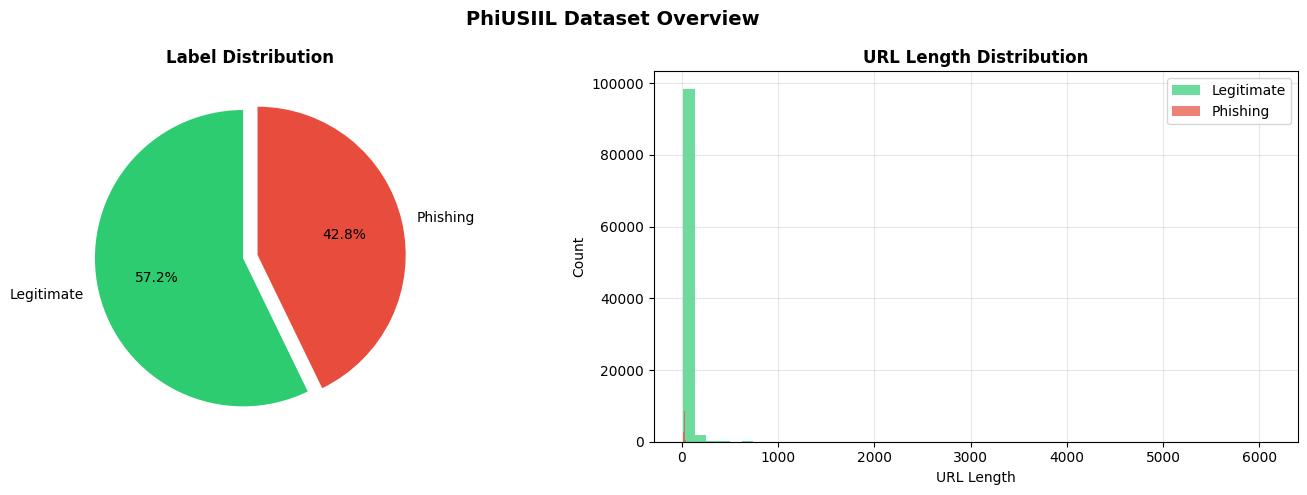

Saved to reports/dataset_overview.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Label distribution
label_counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(label_counts,
            labels=['Legitimate', 'Phishing'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0.05))
axes[0].set_title('Label Distribution', fontweight='bold')

# Chart 2 - URL length distribution
axes[1].hist(df[df['label']==0]['URLLength'],
             bins=50, alpha=0.7,
             color='#2ecc71', label='Legitimate')
axes[1].hist(df[df['label']==1]['URLLength'],
             bins=50, alpha=0.7,
             color='#e74c3c', label='Phishing')
axes[1].set_xlabel('URL Length')
axes[1].set_ylabel('Count')
axes[1].set_title('URL Length Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PhiUSIIL Dataset Overview',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/dataset_overview.png', dpi=150)
plt.show()
print("Saved to reports/dataset_overview.png")

In [8]:
# Verify labels by checking known features
print("Checking label meaning...")
print("\nURLSimilarityIndex by label:")
print(df.groupby('label')['URLSimilarityIndex'].mean())
print("\nIsHTTPS by label:")
print(df.groupby('label')['IsHTTPS'].mean())
print("\nIsDomainIP by label:")
print(df.groupby('label')['IsDomainIP'].mean())
print("\nHasObfuscation by label:")
print(df.groupby('label')['HasObfuscation'].mean())
print("\nHasPasswordField by label:")
print(df.groupby('label')['HasPasswordField'].mean())
print("\nBank by label:")
print(df.groupby('label')['Bank'].mean())

# Check a few specific URLs we know
print("\n--- Checking specific known URLs ---")
google = df[df['URL'].str.contains('google.com', na=False)]
if len(google) > 0:
    print(f"Google URLs label: {google['label'].values}")

# Check for obvious phishing patterns
suspicious = df[df['URL'].str.contains('verify|login|secure|account', 
                                        case=False, na=False)]
print(f"\nURLs with suspicious keywords: {len(suspicious)}")
print(f"Their label distribution:")
print(suspicious['label'].value_counts())

Checking label meaning...

URLSimilarityIndex by label:
label
0     49.616973
1    100.000000
Name: URLSimilarityIndex, dtype: float64

IsHTTPS by label:
label
0    0.492238
1    1.000000
Name: IsHTTPS, dtype: float64

IsDomainIP by label:
label
0    0.00632
1    0.00000
Name: IsDomainIP, dtype: float64

HasObfuscation by label:
label
0    0.004805
1    0.000000
Name: HasObfuscation, dtype: float64

HasPasswordField by label:
label
0    0.053871
1    0.138487
Name: HasPasswordField, dtype: float64

Bank by label:
label
0    0.054346
1    0.181542
Name: Bank, dtype: float64

--- Checking specific known URLs ---
Google URLs label: [0 0 0 ... 0 0 0]

URLs with suspicious keywords: 4759
Their label distribution:
label
0    4698
1      61
Name: count, dtype: int64


In [9]:
# Final verification
print("Verifying label convention...")

# Check LineOfCode - phishing sites often have more code to hide malicious content
print("\nLineOfCode by label:")
print(df.groupby('label')['LineOfCode'].mean())

# Check NoOfExternalRef
print("\nNoOfExternalRef by label:")
print(df.groupby('label')['NoOfExternalRef'].mean())

# Check URLTitleMatchScore
print("\nURLTitleMatchScore by label:")
print(df.groupby('label')['URLTitleMatchScore'].mean())

# Sample more URLs from each class
print("\n--- More Label 0 URLs ---")
print(df[df['label']==0]['URL'].sample(10).values)

print("\n--- More Label 1 URLs ---")
print(df[df['label']==1]['URL'].sample(10).values)

Verifying label convention...

LineOfCode by label:
label
0      65.730467
1    1947.491680
Name: LineOfCode, dtype: float64

NoOfExternalRef by label:
label
0     1.128119
1    85.294601
Name: NoOfExternalRef, dtype: float64

URLTitleMatchScore by label:
label
0    21.198164
1    75.270904
Name: URLTitleMatchScore, dtype: float64

--- More Label 0 URLs ---
<StringArray>
['https://focoeduc.com.br/wp-content/owedk/login.php?cmd=submit_log&id=mtmxmjm2otuxng==mtmxmjm2otuxng==&session=mtmxmjm2otuxng==mtmxmjm2otuxng==',
                                                                                                                       'http://www.coin-hive.com',
                                                                                                           'http://preventseniordiagnosticos.com',
                                                                                                                       'https://www.jexhelp.com/',
                                      

In [10]:
# Swap labels to correct convention
# 0 = Legitimate, 1 = Phishing
print("Before swap:")
print(df['label'].value_counts())

df['label'] = df['label'].apply(lambda x: 1 if x == 0 else 0)

print("\nAfter swap:")
print(df['label'].value_counts())

# Verify with known URLs
print("\nVerification after swap:")
google = df[df['URL'].str.contains('google.com', na=False)]
if len(google) > 0:
    print(f"Google URLs label: {google['label'].unique()} (should be 0 = legitimate)")

suspicious = df[df['URL'].str.contains(
    'weeblysite|web.app|firebaseapp', case=False, na=False)]
print(f"\nFree hosting URLs label: {suspicious['label'].unique()} (should be 1 = phishing)")

print("\nSample Legitimate URLs (label 0):")
print(df[df['label']==0]['URL'].sample(5).values)

print("\nSample Phishing URLs (label 1):")
print(df[df['label']==1]['URL'].sample(5).values)

Before swap:
label
1    134850
0    100945
Name: count, dtype: int64

After swap:
label
0    134850
1    100945
Name: count, dtype: int64

Verification after swap:
Google URLs label: [1] (should be 0 = legitimate)

Free hosting URLs label: [1] (should be 1 = phishing)

Sample Legitimate URLs (label 0):
<StringArray>
[     'https://www.micahaustralia.org', 'https://www.entertheimaginarium.com',
             'https://www.kochava.com',                'https://www.path.org',
    'https://www.mindstormstudios.com']
Length: 5, dtype: str

Sample Phishing URLs (label 1):
<StringArray>
[                                                                                                                                                                    'https://servicioszonacmctrujillo.com/clientehbpj/(s(har44janr4orgjy1sdpcswbr))/wflogin.aspx',
 'http://129.226.211.41/interactivelogin?continue=https://accounts.google.com/?&amp;followup=https://accounts.google.com/?&amp;passive=1209600&amp;xrealip=

In [11]:
# Deep investigation
print("=== GOOGLE URLs ===")
google_urls = df[df['URL'].str.contains('google.com', na=False)]
print(f"Total Google URLs: {len(google_urls)}")
print(google_urls[['URL', 'label', 'URLSimilarityIndex', 
                    'LineOfCode', 'NoOfExternalRef']].head(10))

print("\n=== CHECKING ORIGINAL PAPER LABELS ===")
# URLSimilarityIndex of 100 means very similar to legitimate sites
# In original dataset label 1 had URLSimilarityIndex of 100
# After our swap label 0 has URLSimilarityIndex of 100
print("URLSimilarityIndex by label after swap:")
print(df.groupby('label')['URLSimilarityIndex'].mean())

print("\nLineOfCode by label after swap:")
print(df.groupby('label')['LineOfCode'].mean())

print("\nIsHTTPS by label after swap:")
print(df.groupby('label')['IsHTTPS'].mean())

print("\nIsDomainIP by label after swap:")
print(df.groupby('label')['IsDomainIP'].mean())

print("\nHasObfuscation by label after swap:")
print(df.groupby('label')['HasObfuscation'].mean())

# Check the Google Docs phishing URL
print("\n=== GOOGLE DOCS PHISHING URL ===")
gdocs = df[df['URL'].str.contains('docs.google.com/presentation', na=False)]
print(f"Google Docs presentation URLs: {len(gdocs)}")
if len(gdocs) > 0:
    print(gdocs[['URL', 'label', 'URLSimilarityIndex', 'LineOfCode']].head(5))

=== GOOGLE URLs ===
Total Google URLs: 1241
                                                    URL  label  \
401   http://43.134.167.94/servicelogin?passive=1209...      1   
402   https://docs.google.com/forms/d/1casphevkfdaz2...      1   
924   https://docs.google.com/forms/d/e/1faipqlscckv...      1   
1093  https://www.google.com/url?q=https://ipfs.io/i...      1   
1205  http://43.128.92.128/servicelogin?passive=1209...      1   
1362  http://43.134.167.94/v3/signin/identifier?dsh=...      1   
2125  https://docs.google.com/forms/d/e/1faipqlsdneg...      1   
2260  https://docs.google.com/forms/d/e/1faipqlsfp1e...      1   
2359  https://docs.google.com/forms/d/e/1faipqlsc-nv...      1   
2481  http://43.153.207.103/v3/signin/identifier?dsh...      1   

      URLSimilarityIndex  LineOfCode  NoOfExternalRef  
401             4.813395           2                0  
402            19.882715          11                1  
924            16.782787          18                2  
1093 

In [12]:
# Revert swap — go back to original labels
df['label'] = df['label'].apply(lambda x: 1 if x == 0 else 0)

print("Reverted to original labels:")
print(df['label'].value_counts())

Reverted to original labels:
label
1    134850
0    100945
Name: count, dtype: int64


In [13]:
# Revert our swap first
df['label'] = df['label'].apply(lambda x: 1 if x == 0 else 0)

# Now remap correctly
# Original 0 = Phishing → our 1
# Original 1 = Legitimate → our 0
df['label'] = df['label'].apply(lambda x: 0 if x == 1 else 1)

# Verify
print("Final label distribution:")
print(df['label'].value_counts())
print("\nLabel meaning:")
print("0 = Legitimate")
print("1 = Phishing")

print("\nVerification:")
print("\nSample Legitimate (0):")
print(df[df['label']==0]['URL'].sample(5).values)

print("\nSample Phishing (1):")
print(df[df['label']==1]['URL'].sample(5).values)

# Check features make sense
print("\nURLSimilarityIndex by label:")
print(df.groupby('label')['URLSimilarityIndex'].mean())
print("(Legitimate should be higher)")

print("\nLineOfCode by label:")
print(df.groupby('label')['LineOfCode'].mean())
print("(Legitimate should be higher)")

Final label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Label meaning:
0 = Legitimate
1 = Phishing

Verification:

Sample Legitimate (0):
<StringArray>
[                                                             'http://www.redirect-link.com',
                                                     'http://www.englishlessons-houston.com',
 'https://ipfs.litnet.work/ipfs/bafybeifxlpdlx2snbkvognwevpum5qozogdlcctiboav55v3xeud2vcmqm',
                                                                          'http://www.de.ht',
                                                   'https://attnotifyservice23.square.site/']
Length: 5, dtype: str

Sample Phishing (1):
<StringArray>
[    'https://www.multtelas.net.br',        'https://www.health.gov.gy',
 'https://www.masonryinstitute.org',      'https://www.yancheng.gov.cn',
          'https://www.dpsskis.com']
Length: 5, dtype: str

URLSimilarityIndex by label:
label
0     49.616973
1    100.000000
Name: URLSimilarityI

In [14]:
# Reload the dataset completely fresh
df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")

print("Original labels:")
print(df['label'].value_counts())

print("\nOriginal label 0 samples:")
print(df[df['label']==0]['URL'].sample(5).values)

print("\nOriginal label 1 samples:")
print(df[df['label']==1]['URL'].sample(5).values)

print("\nOriginal URLSimilarityIndex by label:")
print(df.groupby('label')['URLSimilarityIndex'].mean())

print("\nOriginal LineOfCode by label:")
print(df.groupby('label')['LineOfCode'].mean())

Original labels:
label
1    134850
0    100945
Name: count, dtype: int64

Original label 0 samples:
<StringArray>
[                                            'https://lensnetworking.xyz/',
                                     'https://m.t6755.com/chs/?code=20131',
                                              'http://www.odsakmdfnbs.com',
 'http://petersenhealthcare-access-pdf.gq/secure/document/authentication/',
                                         'http://www.mmapi001.camerac.xyz']
Length: 5, dtype: str

Original label 1 samples:
<StringArray>
[              'https://www.abca.org', 'https://www.clipperflyingboats.com',
             'https://www.hiw.org.uk',            'https://www.dgmlive.com',
  'https://www.cityofspartanburg.org']
Length: 5, dtype: str

Original URLSimilarityIndex by label:
label
0     49.616973
1    100.000000
Name: URLSimilarityIndex, dtype: float64

Original LineOfCode by label:
label
0      65.730467
1    1947.491680
Name: LineOfCode, dtype: float64


In [15]:
# Reload fresh
df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")

# Remap: 0=Phishing→1, 1=Legitimate→0
df['label'] = df['label'].map({0: 1, 1: 0})

# Verify
print("Final label distribution:")
print(df['label'].value_counts())
print("\n0 = Legitimate")
print("1 = Phishing")

print("\nSample Legitimate (0):")
print(df[df['label']==0]['URL'].sample(5).values)

print("\nSample Phishing (1):")
print(df[df['label']==1]['URL'].sample(5).values)

print("\nURLSimilarityIndex by label:")
print(df.groupby('label')['URLSimilarityIndex'].mean())
print("Legitimate should be HIGHER than Phishing")

print("\nLineOfCode by label:")
print(df.groupby('label')['LineOfCode'].mean())
print("Legitimate should be HIGHER than Phishing")


Final label distribution:
label
0    134850
1    100945
Name: count, dtype: int64

0 = Legitimate
1 = Phishing

Sample Legitimate (0):
<StringArray>
[         'https://www.munster-express.ie',
              'https://www.crowdfundme.it',
 'https://www.imperialhoteleumundi.com.au',
           'https://www.airfieldwines.com',
                    'https://www.wkok.com']
Length: 5, dtype: str

Sample Phishing (1):
<StringArray>
[                  'http://www.halemdus.000space.com',
                       'https://kilik-eb4d5.web.app/',
                           'http://www.mswetshop.xyz',
                       'http://www.diffenfabrics.com',
 'http://attdomaincashservice-107211.weeblysite.com/']
Length: 5, dtype: str

URLSimilarityIndex by label:
label
0    100.000000
1     49.616973
Name: URLSimilarityIndex, dtype: float64
Legitimate should be HIGHER than Phishing

LineOfCode by label:
label
0    1947.491680
1      65.730467
Name: LineOfCode, dtype: float64
Legitimate should be HIGHER th

In [16]:
print("=" * 50)
print("URL LENGTH OUTLIERS")
print("=" * 50)
print(f"Max URL length: {df['URLLength'].max()}")
print(f"URLs longer than 500 chars: {(df['URLLength'] > 500).sum()}")
print(f"URLs longer than 1000 chars: {(df['URLLength'] > 1000).sum()}")
print(f"URLs longer than 2000 chars: {(df['URLLength'] > 2000).sum()}")

print("\n" + "=" * 50)
print("CLASS IMBALANCE")
print("=" * 50)
print(f"Legitimate (0): {(df['label']==0).sum():,}")
print(f"Phishing   (1): {(df['label']==1).sum():,}")
ratio = (df['label']==0).sum() / (df['label']==1).sum()
print(f"Ratio: {ratio:.2f}")
print(f"Imbalance: {'Acceptable (< 1.5)' if ratio < 1.5 else 'Needs balancing'}")

print("\n" + "=" * 50)
print("COLUMNS TO DROP")
print("=" * 50)
print("FILENAME - just file reference")
print("Title    - text column needs special handling")
print("TLD      - text column needs encoding")
print("URL      - keep for reference only")

print("\n" + "=" * 50)
print("DUPLICATE CHECK")
print("=" * 50)
print(f"Duplicate URLs: {df.duplicated(subset='URL').sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

URL LENGTH OUTLIERS
Max URL length: 6097
URLs longer than 500 chars: 123
URLs longer than 1000 chars: 19
URLs longer than 2000 chars: 8

CLASS IMBALANCE
Legitimate (0): 134,850
Phishing   (1): 100,945
Ratio: 1.34
Imbalance: Acceptable (< 1.5)

COLUMNS TO DROP
FILENAME - just file reference
Title    - text column needs special handling
TLD      - text column needs encoding
URL      - keep for reference only

DUPLICATE CHECK
Duplicate URLs: 425
Duplicate rows: 0


In [17]:
# Step 1 — Remove duplicates
before = len(df)
df = df.drop_duplicates(subset='URL')
print(f"Removed {before - len(df)} duplicate URLs")

# Step 2 — Remove extreme URL length outliers
before = len(df)
df = df[df['URLLength'] <= 500]
print(f"Removed {before - len(df)} URLs longer than 500 chars")

# Step 3 — Drop non-numeric columns we can't use directly
# Keep URL for feature extraction later
df_clean = df.drop(columns=['FILENAME', 'Title', 'TLD'])

print(f"\nClean dataset shape: {df_clean.shape}")
print(f"\nRemaining columns: {df_clean.columns.tolist()}")
print(f"\nLabel distribution after cleaning:")
print(df_clean['label'].value_counts())

Removed 425 duplicate URLs
Removed 123 URLs longer than 500 chars

Clean dataset shape: (235247, 53)

Remaining columns: ['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef

In [18]:
# Balance dataset by undersampling the majority class
print("Before balancing:")
print(df_clean['label'].value_counts())

# Get minority class count
minority_count = df_clean['label'].value_counts().min()
print(f"\nMinority class count: {minority_count:,}")

# Sample equal numbers from each class
legit = df_clean[df_clean['label']==0].sample(
    n=minority_count, random_state=42
)
phish = df_clean[df_clean['label']==1].sample(
    n=minority_count, random_state=42
)

# Combine and shuffle
df_clean = pd.concat([legit, phish], ignore_index=True)
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(df_clean['label'].value_counts())
print(f"\nTotal URLs: {len(df_clean):,}")
print(f"Ratio: {df_clean['label'].value_counts()[0]/df_clean['label'].value_counts()[1]:.2f}")
print("✅ Perfectly balanced!")

Before balancing:
label
0    134850
1    100397
Name: count, dtype: int64

Minority class count: 100,397

After balancing:
label
1    100397
0    100397
Name: count, dtype: int64

Total URLs: 200,794
Ratio: 1.00
✅ Perfectly balanced!


In [22]:
 
print("✅ Saved to data/processed/phishing_clean.csv")
print(f"Shape: {df_clean.shape}")
print(f"Features available: {df_clean.shape[1] - 2} (excluding URL and label)")

✅ Saved to data/processed/phishing_clean.csv
Shape: (200794, 53)
Features available: 51 (excluding URL and label)


In [23]:
def extract_custom_features(url):
    url = str(url).strip()
    url_lower = url.lower()

    if "://" in url:
        domain_part = url.split("://")[1].split("/")[0]
        path_part = url.split("://")[1].split("/", 1)[-1] \
            if "/" in url.split("://")[1] else ""
    else:
        domain_part = url.split("/")[0]
        path_part = url.split("/", 1)[-1] if "/" in url else ""

    total_len = max(len(url), 1)
    domain_len = max(len(domain_part), 1)

    suspicious_keywords = [
        "login", "signin", "verify", "update", "secure", "account",
        "banking", "confirm", "password", "credential", "suspend",
        "unusual", "access", "locked", "unlock", "validate", "submit",
        "paypal", "amazon", "apple", "google", "microsoft", "netflix",
        "instagram", "facebook", "twitter", "bank", "ebay", "support"
    ]
    brand_names = [
        "paypal", "amazon", "apple", "google", "microsoft",
        "netflix", "facebook", "instagram", "twitter", "ebay"
    ]
    suspicious_tlds = [
        ".tk", ".ml", ".ga", ".cf", ".gq", ".xyz", ".top",
        ".club", ".online", ".site", ".info", ".biz", ".mom",
        ".pw", ".cc", ".ws", ".work", ".gd"
    ]
    urgency_words = [
        "urgent", "immediately", "expire", "suspend", "limited",
        "warning", "alert", "critical", "important", "verify-now"
    ]
    financial_words = [
        "payment", "invoice", "billing", "transaction", "wallet",
        "credit", "debit", "refund", "cashout", "withdraw", "deposit"
    ]
    free_hosting = [
        "wordpress", "wixsite", "weebly", "blogspot", "github.io",
        "netlify", "000webhostapp", "web.app", "firebaseapp",
        "vercel.app", "square.site", "wixstudio", "yolasite",
        "weeblysite", "pantheonsite", "workers.dev", "duckdns"
    ]

    try:
        vowels = sum(domain_part.lower().count(v) for v in "aeiou")

        return {
            "custom_num_hyphens":           url.count("-"),
            "custom_num_at":                url.count("@"),
            "custom_num_percent":           url.count("%"),
            "custom_num_underscores":       url.count("_"),
            "custom_num_slashes":           url.count("/"),
            "custom_has_protocol":          int("://" in url),
            "custom_uses_http":             int(url_lower.startswith("http://")),
            "custom_has_www":               int("www." in url_lower),
            "custom_domain_has_hyphen":     int("-" in domain_part),
            "custom_domain_starts_num":     int(domain_part[0].isdigit()
                                               if domain_part else 0),
            "custom_domain_vowel_ratio":    vowels / domain_len,
            "custom_domain_digit_ratio":    sum(c.isdigit() for c in domain_part)
                                           / domain_len,
            "custom_has_multiple_tlds":     int(bool(re.search(
                                               r"\.(com|net|org|edu|gov)\.",
                                               domain_part))),
            "custom_path_depth":            len([p for p in
                                               path_part.split("/") if p]),
            "custom_path_has_exe":          int(any(ext in url_lower for ext in
                                               [".exe", ".zip", ".rar",
                                                ".bat", ".php", ".js"])),
            "custom_path_has_login":        int("login" in path_part.lower()),
            "custom_path_has_encoded":      int("%" in path_part),
            "custom_has_ip":                int(bool(re.search(
                                               r"\d+\.\d+\.\d+\.\d+", url))),
            "custom_has_at_symbol":         int("@" in url),
            "custom_has_port":              int(bool(re.search(
                                               r":\d{4,5}", url))),
            "custom_has_hex":               int(bool(re.search(
                                               r"%[0-9a-f]{2}", url))),
            "custom_is_shortened":          int(bool(re.search(
                                               r"bit\.ly|goo\.gl|tinyurl"
                                               r"|t\.co|ow\.ly", url_lower))),
            "custom_has_typosquat":         int(bool(re.search(
                                               r"paypa[^l]|go+gle|"
                                               r"amaz[^o]n|faceb[^o]ok",
                                               url_lower))),
            "custom_has_suspicious_kw":     int(any(w in url_lower
                                               for w in suspicious_keywords)),
            "custom_num_suspicious_kw":     sum(w in url_lower
                                               for w in suspicious_keywords),
            "custom_has_brand_name":        int(any(b in url_lower
                                               for b in brand_names)),
            "custom_has_suspicious_tld":    int(any(url_lower.endswith(t)
                                               for t in suspicious_tlds)),
            "custom_has_urgency_words":     int(any(w in url_lower
                                               for w in urgency_words)),
            "custom_has_financial_words":   int(any(w in url_lower
                                               for w in financial_words)),
            "custom_is_free_hosting":       int(any(h in url_lower
                                               for h in free_hosting)),
            "custom_url_entropy":           -sum(
                                               (url.count(c) / total_len) *
                                               np.log2(url.count(c) / total_len)
                                               for c in set(url)
                                               if url.count(c) > 0),
            "custom_ratio_digits":          sum(c.isdigit() for c in url)
                                           / total_len,
            "custom_ratio_special":         sum(not c.isalnum() for c in url)
                                           / total_len,
            "custom_ratio_alpha":           sum(c.isalpha() for c in url)
                                           / total_len,
            "custom_num_redirects":         url.count("http", 1),
        }

    except Exception:
        return {k: 0 for k in [
            "custom_num_hyphens", "custom_num_at", "custom_num_percent",
            "custom_num_underscores", "custom_num_slashes",
            "custom_has_protocol", "custom_uses_http", "custom_has_www",
            "custom_domain_has_hyphen", "custom_domain_starts_num",
            "custom_domain_vowel_ratio", "custom_domain_digit_ratio",
            "custom_has_multiple_tlds", "custom_path_depth",
            "custom_path_has_exe", "custom_path_has_login",
            "custom_path_has_encoded", "custom_has_ip",
            "custom_has_at_symbol", "custom_has_port", "custom_has_hex",
            "custom_is_shortened", "custom_has_typosquat",
            "custom_has_suspicious_kw", "custom_num_suspicious_kw",
            "custom_has_brand_name", "custom_has_suspicious_tld",
            "custom_has_urgency_words", "custom_has_financial_words",
            "custom_is_free_hosting", "custom_url_entropy",
            "custom_ratio_digits", "custom_ratio_special",
            "custom_ratio_alpha", "custom_num_redirects"
        ]}

print("✅ Function defined!")

✅ Function defined!


In [24]:
print("Extracting custom features... please wait 3-5 minutes")
custom_features = df_clean['URL'].apply(
    extract_custom_features
).apply(pd.Series)

print("✅ Done!")
print(f"Custom features shape: {custom_features.shape}")
print(custom_features.head())

Extracting custom features... please wait 3-5 minutes
✅ Done!
Custom features shape: (200794, 35)
   custom_num_hyphens  custom_num_at  custom_num_percent  \
0                 3.0            0.0                 0.0   
1                 0.0            0.0                 0.0   
2                 0.0            0.0                 0.0   
3                 0.0            0.0                 0.0   
4                 0.0            0.0                 0.0   

   custom_num_underscores  custom_num_slashes  custom_has_protocol  \
0                     2.0                11.0                  1.0   
1                     0.0                 3.0                  1.0   
2                     0.0                 2.0                  1.0   
3                     0.0                 2.0                  1.0   
4                     0.0                 2.0                  1.0   

   custom_uses_http  custom_has_www  custom_domain_has_hyphen  \
0               1.0             0.0                    

In [25]:
def extract_lexical_features(url):
    url = str(url).strip()
    url_lower = url.lower()
    
    if "://" in url:
        domain_part = url.split("://")[1].split("/")[0]
        path_part = url.split("://")[1].split("/", 1)[-1] \
            if "/" in url.split("://")[1] else ""
    else:
        domain_part = url.split("/")[0]
        path_part = url.split("/", 1)[-1] if "/" in url else ""
    
    # Remove special chars to get words
    words = re.findall(r'[a-zA-Z]+', url)
    domain_words = re.findall(r'[a-zA-Z]+', domain_part)
    
    total_len = max(len(url), 1)
    domain_len = max(len(domain_part), 1)
    
    try:
        return {
            # Word analysis
            "lex_num_words":                len(words),
            "lex_avg_word_length":          np.mean([len(w) for w in words])
                                            if words else 0,
            "lex_longest_word_length":      max([len(w) for w in words])
                                            if words else 0,
            "lex_shortest_word_length":     min([len(w) for w in words])
                                            if words else 0,
            "lex_num_unique_chars":         len(set(url_lower)),
            "lex_char_diversity":           len(set(url_lower)) / total_len,
            
            # Consonant/vowel analysis
            "lex_consonant_ratio":          sum(c in "bcdfghjklmnpqrstvwxyz"
                                            for c in url_lower) / total_len,
            "lex_vowel_ratio":              sum(c in "aeiou"
                                            for c in url_lower) / total_len,
            "lex_domain_consonant_ratio":   sum(c in "bcdfghjklmnpqrstvwxyz"
                                            for c in domain_part.lower())
                                            / domain_len,
            
            # Random string detection
            "lex_has_random_string":        int(bool(re.search(
                                            r'[a-z0-9]{12,}', url_lower))),
            "lex_longest_consonant_seq":    max([len(m.group()) for m in
                                            re.finditer(r'[bcdfghjklmnpqrstvwxyz]+',
                                            url_lower)] or [0]),
            "lex_longest_digit_seq":        max([len(m.group()) for m in
                                            re.finditer(r'\d+', url)] or [0]),
            
            # Domain word analysis
            "lex_num_domain_words":         len(domain_words),
            "lex_avg_domain_word_len":      np.mean([len(w) for w in domain_words])
                                            if domain_words else 0,
            
            # Repetition patterns
            "lex_has_repeated_chars":       int(bool(re.search(
                                            r'(.)\1{2,}', url_lower))),
            "lex_has_repeated_digits":      int(bool(re.search(
                                            r'(\d)\1{2,}', url))),
            
            # Number patterns
            "lex_num_numbers_in_domain":    len(re.findall(r'\d+', domain_part)),
            "lex_has_year_in_domain":       int(bool(re.search(
                                            r'20[0-9]{2}', domain_part))),
            
            # Path word analysis
            "lex_num_path_words":           len(re.findall(r'[a-zA-Z]+', path_part)),
            "lex_path_has_hex_string":      int(bool(re.search(
                                            r'[0-9a-f]{8,}', path_part.lower()))),
        }
    
    except Exception:
        return {k: 0 for k in [
            "lex_num_words", "lex_avg_word_length", "lex_longest_word_length",
            "lex_shortest_word_length", "lex_num_unique_chars",
            "lex_char_diversity", "lex_consonant_ratio", "lex_vowel_ratio",
            "lex_domain_consonant_ratio", "lex_has_random_string",
            "lex_longest_consonant_seq", "lex_longest_digit_seq",
            "lex_num_domain_words", "lex_avg_domain_word_len",
            "lex_has_repeated_chars", "lex_has_repeated_digits",
            "lex_num_numbers_in_domain", "lex_has_year_in_domain",
            "lex_num_path_words", "lex_path_has_hex_string"
        ]}

print("✅ Lexical features function defined!")

✅ Lexical features function defined!


In [26]:
# Install if needed: pip install fuzzywuzzy python-Levenshtein
try:
    from fuzzywuzzy import fuzz
    FUZZY_AVAILABLE = True
except:
    FUZZY_AVAILABLE = False
    print("fuzzywuzzy not available — using basic brand detection")

KNOWN_BRANDS = [
    "paypal", "amazon", "apple", "google", "microsoft",
    "netflix", "facebook", "instagram", "twitter", "ebay",
    "linkedin", "dropbox", "spotify", "whatsapp", "gmail",
    "outlook", "yahoo", "chase", "wellsfargo", "bankofamerica",
    "citibank", "hsbc", "barclays", "santander"
]

def extract_brand_features(url):
    url = str(url).strip()
    url_lower = url.lower()
    
    if "://" in url:
        domain_part = url.split("://")[1].split("/")[0]
        path_part = url.split("://")[1].split("/", 1)[-1] \
            if "/" in url.split("://")[1] else ""
    else:
        domain_part = url.split("/")[0]
        path_part = url.split("/", 1)[-1] if "/" in url else ""
    
    # Remove www. for cleaner comparison
    clean_domain = domain_part.replace("www.", "")
    
    try:
        # Basic brand detection
        brand_in_domain = int(any(b in clean_domain for b in KNOWN_BRANDS))
        brand_in_path = int(any(b in path_part.lower() for b in KNOWN_BRANDS))
        brand_in_subdomain = 0
        
        # Check if brand is in subdomain but not main domain
        domain_parts = clean_domain.split(".")
        if len(domain_parts) > 2:
            subdomain = ".".join(domain_parts[:-2])
            brand_in_subdomain = int(any(b in subdomain for b in KNOWN_BRANDS))
        
        # Fuzzy matching for typosquatting
        if FUZZY_AVAILABLE:
            # Get main domain name without TLD
            main_domain = domain_parts[-2] if len(domain_parts) >= 2 else clean_domain
            
            max_fuzzy_score = max([
                fuzz.ratio(main_domain, brand)
                for brand in KNOWN_BRANDS
            ], default=0)
            
            is_typosquat_fuzzy = int(max_fuzzy_score > 70
                                    and max_fuzzy_score < 100)
        else:
            max_fuzzy_score = 0
            is_typosquat_fuzzy = int(bool(re.search(
                r'paypa[^l]|go+gle|amaz[^o]n|faceb[^o]ok|'
                r'micros[^o]ft|netfl[^i]x|twitt[^e]r',
                url_lower)))
        
        # Brand in path but NOT in domain (suspicious)
        brand_path_not_domain = int(
            brand_in_path and not brand_in_domain
        )
        
        # Multiple brands in URL (suspicious)
        brands_count = sum(b in url_lower for b in KNOWN_BRANDS)
        
        return {
            "brand_in_domain":              brand_in_domain,
            "brand_in_path":                brand_in_path,
            "brand_in_subdomain":           brand_in_subdomain,
            "brand_path_not_domain":        brand_path_not_domain,
            "brand_multiple_brands":        int(brands_count > 1),
            "brand_count":                  brands_count,
            "brand_max_fuzzy_score":        max_fuzzy_score / 100,
            "brand_is_typosquat":           is_typosquat_fuzzy,
            "brand_domain_impersonation":   int(brand_in_domain and
                                            len(domain_parts) > 2),
        }
    
    except Exception:
        return {k: 0 for k in [
            "brand_in_domain", "brand_in_path", "brand_in_subdomain",
            "brand_path_not_domain", "brand_multiple_brands",
            "brand_count", "brand_max_fuzzy_score",
            "brand_is_typosquat", "brand_domain_impersonation"
        ]}

print("✅ Brand impersonation features function defined!")

✅ Brand impersonation features function defined!


In [28]:
# Top legitimate TLDs by usage
TOP_LEGITIMATE_TLDS = {
    'com': 0.9, 'org': 0.85, 'net': 0.8, 'edu': 0.95,
    'gov': 0.98, 'uk': 0.85, 'de': 0.85, 'fr': 0.85,
    'au': 0.85, 'ca': 0.85, 'jp': 0.85, 'it': 0.85,
    'nl': 0.85, 'se': 0.85, 'no': 0.85, 'fi': 0.85,
    'ch': 0.85, 'at': 0.85, 'nz': 0.85, 'ie': 0.85
}

# High risk TLDs
HIGH_RISK_TLDS = {
    'tk': 0.9, 'ml': 0.85, 'ga': 0.85, 'cf': 0.85,
    'gq': 0.85, 'xyz': 0.7, 'top': 0.7, 'club': 0.65,
    'online': 0.6, 'site': 0.6, 'info': 0.5, 'biz': 0.5,
    'pw': 0.8, 'cc': 0.7, 'ws': 0.65, 'work': 0.7,
    'gd': 0.7, 'mom': 0.7, 'rest': 0.65, 'icu': 0.75
}

def extract_tld_features(url):
    url = str(url).strip()
    url_lower = url.lower()
    
    if "://" in url:
        domain_part = url.split("://")[1].split("/")[0]
    else:
        domain_part = url.split("/")[0]
    
    clean_domain = domain_part.replace("www.", "")
    parts = clean_domain.split(".")
    
    try:
        # Extract TLD
        tld = parts[-1].lower() if parts else ""
        second_level = parts[-2].lower() if len(parts) >= 2 else ""
        
        # TLD risk scores
        tld_legitimate_score = TOP_LEGITIMATE_TLDS.get(tld, 0.5)
        tld_risk_score = HIGH_RISK_TLDS.get(tld, 0.0)
        
        return {
            "tld_is_high_risk":             int(tld in HIGH_RISK_TLDS),
            "tld_risk_score":               tld_risk_score,
            "tld_legitimate_score":         tld_legitimate_score,
            "tld_is_country_code":          int(len(tld) == 2),
            "tld_is_common_legit":          int(tld in TOP_LEGITIMATE_TLDS),
            "tld_length":                   len(tld),
            "tld_is_new_gtld":              int(tld not in TOP_LEGITIMATE_TLDS
                                            and len(tld) > 3),
            "tld_num_domain_parts":         len(parts),
            "tld_second_level_length":      len(second_level),
            "tld_second_level_has_digits":  int(bool(re.search(
                                            r'\d', second_level))),
            "tld_second_level_has_hyphen":  int("-" in second_level),
        }
    
    except Exception:
        return {k: 0 for k in [
            "tld_is_high_risk", "tld_risk_score", "tld_legitimate_score",
            "tld_is_country_code", "tld_is_common_legit", "tld_length",
            "tld_is_new_gtld", "tld_num_domain_parts",
            "tld_second_level_length", "tld_second_level_has_digits",
            "tld_second_level_has_hyphen"
        ]}

print("✅ TLD intelligence features function defined!")

✅ TLD intelligence features function defined!


In [29]:
def extract_combination_features(url, row):
    """
    Features that combine URL patterns with page content features.
    row = the dataset row with existing features
    """
    url = str(url).strip()
    url_lower = url.lower()
    
    try:
        has_https = int(url_lower.startswith("https"))
        has_login_kw = int("login" in url_lower or "signin" in url_lower)
        has_verify_kw = int("verify" in url_lower or "confirm" in url_lower)
        has_brand = int(any(b in url_lower for b in KNOWN_BRANDS))
        has_suspicious_tld = int(bool(re.search(
            r'\.(tk|ml|ga|cf|gq|xyz|top|club|online|site)$',
            url_lower)))
        url_length = len(url)
        
        return {
            # Dangerous combinations
            "combo_brand_suspicious_tld":   int(has_brand and
                                            has_suspicious_tld),
            "combo_login_no_https":         int(has_login_kw and
                                            not has_https),
            "combo_verify_no_https":        int(has_verify_kw and
                                            not has_https),
            "combo_brand_path_not_domain":  int(
                                            has_brand and
                                            any(b in url_lower.split("/", 3)[-1]
                                            for b in KNOWN_BRANDS)
                                            if "/" in url else 0),
            "combo_long_url_many_params":   int(url_length > 100 and
                                            url.count("?") > 0 and
                                            url.count("&") > 2),
            "combo_ip_with_path":           int(
                                            bool(re.search(
                                            r'\d+\.\d+\.\d+\.\d+', url))
                                            and "/" in url),
            "combo_free_host_brand":        int(
                                            any(h in url_lower for h in [
                                            "wordpress", "wixsite", "weebly",
                                            "blogspot", "web.app", "firebaseapp",
                                            "vercel.app", "workers.dev"])
                                            and has_brand),
            "combo_has_password_no_https":  int(
                                            row.get('HasPasswordField', 0) == 1
                                            and not has_https),
            "combo_redirect_suspicious":    int(
                                            row.get('NoOfURLRedirect', 0) > 2
                                            and has_suspicious_tld),
            "combo_hidden_field_login":     int(
                                            row.get('HasHiddenFields', 0) == 1
                                            and has_login_kw),
        }
    
    except Exception:
        return {k: 0 for k in [
            "combo_brand_suspicious_tld", "combo_login_no_https",
            "combo_verify_no_https", "combo_brand_path_not_domain",
            "combo_long_url_many_params", "combo_ip_with_path",
            "combo_free_host_brand", "combo_has_password_no_https",
            "combo_redirect_suspicious", "combo_hidden_field_login"
        ]}

print("✅ Combination features function defined!")

✅ Combination features function defined!


In [50]:
print("Extracting lexical features... please wait")
lexical_df = df_clean['URL'].apply(
    extract_lexical_features
).apply(pd.Series)
print(f"✅ Lexical features: {lexical_df.shape[1]}")

print("\nExtracting brand features... please wait")
brand_df = df_clean['URL'].apply(
    extract_brand_features
).apply(pd.Series)
print(f"✅ Brand features: {brand_df.shape[1]}")

print("\nExtracting TLD features... please wait")
tld_df = df_clean['URL'].apply(
    extract_tld_features
).apply(pd.Series)
print(f"✅ TLD features: {tld_df.shape[1]}")

print("\nExtracting combination features... please wait")
combo_df = pd.DataFrame([
    extract_combination_features(row['URL'], row)
    for _, row in df_clean.iterrows()
])
print(f"✅ Combination features: {combo_df.shape[1]}")

Extracting lexical features... please wait
✅ Lexical features: 20

Extracting brand features... please wait
✅ Brand features: 9

Extracting TLD features... please wait
✅ TLD features: 11

Extracting combination features... please wait
✅ Combination features: 10


In [51]:
# Combine ALL features
df_final = pd.concat([
    df_clean.drop(columns=['URL']),   # 50 dataset features
    custom_features,                   # 35 custom URL features
    lexical_df,                        # 20 lexical features
    brand_df,                          # 9 brand features
    tld_df,                            # 11 TLD features
    combo_df,                          # 10 combination features
], axis=1)

# Move label to end
cols = [c for c in df_final.columns if c != 'label'] + ['label']
df_final = df_final[cols]

# Fix label type
df_final['label'] = df_final['label'].astype(int)

print(f"=" * 50)
print(f"FINAL DATASET SUMMARY")
print(f"=" * 50)
print(f"Total rows:     {df_final.shape[0]:,}")
print(f"Total features: {df_final.shape[1] - 1}")
print(f"Any NaN:        {df_final.isnull().sum().sum()}")
print(f"\nLabel distribution:")
print(df_final['label'].value_counts())
print(f"\nFeature groups:")
print(f"  Dataset features:     50")
print(f"  Custom URL features:  35")
print(f"  Lexical features:     20")
print(f"  Brand features:        9")
print(f"  TLD features:         11")
print(f"  Combination features: 10")
print(f"  {'─'*25}")
print(f"  Total:               135")

FINAL DATASET SUMMARY
Total rows:     200,794
Total features: 136
Any NaN:        0

Label distribution:
label
1    100397
0    100397
Name: count, dtype: int64

Feature groups:
  Dataset features:     50
  Custom URL features:  35
  Lexical features:     20
  Brand features:        9
  TLD features:         11
  Combination features: 10
  ─────────────────────────
  Total:               135


In [52]:
import os

# Ensure directory exists
os.makedirs("../data/processed", exist_ok=True)

# Save with error handling
try:
   df_final.to_csv("../data/processed/phishing_features.csv", index=False)
   print("✅ Saved to data/processed/phishing_features.csv")
   print(f"Shape: {df_final.shape}")
except PermissionError:
   print("❌ Permission denied. Trying alternative path...")
   # Try saving to current directory
   df_final.to_csv("phishing_features.csv", index=False)
   print("✅ Saved to current directory as phishing_features.csv")
   print(f"Shape: {df_final.shape}")
except Exception as e:
   print(f"❌ Error: {e}")
print("✅ Saved to data/processed/phishing_features.csv")
print(f"Shape: {df_final.shape}")

✅ Saved to data/processed/phishing_features.csv
Shape: (200794, 137)
✅ Saved to data/processed/phishing_features.csv
Shape: (200794, 137)


In [54]:
# Quick feature quality check
print("=" * 50)
print("FEATURE QUALITY CHECK")
print("=" * 50)

# Separate features and label
X = df_final.drop('label', axis=1)
y = df_final['label']

# Check for constant features (zero variance)
constant_features = [col for col in X.columns
                     if X[col].nunique() == 1]
print(f"\nConstant features (useless): {len(constant_features)}")
if constant_features:
    print(constant_features)

# Check for near-constant features
near_constant = [col for col in X.columns
                 if X[col].value_counts(normalize=True).iloc[0] > 0.99]
print(f"\nNear-constant features (>99% same value): {len(near_constant)}")
if near_constant:
    print(near_constant)

# Check top discriminative features
print("\nTop 20 most discriminative features:")
comp = df_final.groupby('label')[X.columns].mean().T
comp.columns = ['Legitimate', 'Phishing']
comp['difference'] = abs(comp['Legitimate'] - comp['Phishing'])
comp = comp.sort_values('difference', ascending=False)
print(comp.head(20).to_string())

FEATURE QUALITY CHECK

Constant features (useless): 2
['custom_has_protocol', 'combo_redirect_suspicious']

Near-constant features (>99% same value): 33
['IsDomainIP', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfAmpersandInURL', 'custom_num_at', 'custom_num_percent', 'custom_has_protocol', 'custom_path_has_encoded', 'custom_has_ip', 'custom_has_at_symbol', 'custom_has_port', 'custom_has_hex', 'custom_has_typosquat', 'custom_has_urgency_words', 'custom_has_financial_words', 'custom_num_redirects', 'lex_has_year_in_domain', 'brand_in_path', 'brand_in_subdomain', 'brand_path_not_domain', 'brand_multiple_brands', 'brand_is_typosquat', 'combo_brand_suspicious_tld', 'combo_login_no_https', 'combo_verify_no_https', 'combo_brand_path_not_domain', 'combo_long_url_many_params', 'combo_ip_with_path', 'combo_free_host_brand', 'combo_has_password_no_https', 'combo_redirect_suspicious', 'combo_hidden_field_login']

Top 20 most discriminative features:


TypeError: dtype 'str' does not support operation 'mean'

In [55]:
# Fix - only use numeric columns for comparison
print("=" * 50)
print("FEATURE QUALITY CHECK")
print("=" * 50)

# Separate features and label
X = df_final.drop('label', axis=1)
y = df_final['label']

# Select only numeric columns
X_numeric = X.select_dtypes(include=[np.number])
print(f"Total features: {X.shape[1]}")
print(f"Numeric features: {X_numeric.shape[1]}")
print(f"Non-numeric features: {X.shape[1] - X_numeric.shape[1]}")

# Show non-numeric columns
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNon-numeric columns to drop: {non_numeric}")

# Check for constant features
constant_features = [col for col in X_numeric.columns
                     if X_numeric[col].nunique() == 1]
print(f"\nConstant features (useless): {len(constant_features)}")
if constant_features:
    print(constant_features)

# Check near-constant features
near_constant = [col for col in X_numeric.columns
                 if X_numeric[col].value_counts(normalize=True).iloc[0] > 0.99]
print(f"\nNear-constant features (>99% same value): {len(near_constant)}")
if near_constant:
    print(near_constant)

# Top discriminative features
print("\nTop 20 most discriminative features:")
comp = df_final.groupby('label')[X_numeric.columns].mean().T
comp.columns = ['Legitimate', 'Phishing']
comp['difference'] = abs(comp['Legitimate'] - comp['Phishing'])
comp = comp.sort_values('difference', ascending=False)
print(comp.head(20).to_string())

FEATURE QUALITY CHECK
Total features: 136
Numeric features: 135
Non-numeric features: 1

Non-numeric columns to drop: ['Domain']

Constant features (useless): 2
['custom_has_protocol', 'combo_redirect_suspicious']

Near-constant features (>99% same value): 33
['IsDomainIP', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfAmpersandInURL', 'custom_num_at', 'custom_num_percent', 'custom_has_protocol', 'custom_path_has_encoded', 'custom_has_ip', 'custom_has_at_symbol', 'custom_has_port', 'custom_has_hex', 'custom_has_typosquat', 'custom_has_urgency_words', 'custom_has_financial_words', 'custom_num_redirects', 'lex_has_year_in_domain', 'brand_in_path', 'brand_in_subdomain', 'brand_path_not_domain', 'brand_multiple_brands', 'brand_is_typosquat', 'combo_brand_suspicious_tld', 'combo_login_no_https', 'combo_verify_no_https', 'combo_brand_path_not_domain', 'combo_long_url_many_params', 'combo_ip_with_path', 'combo_free_host_brand', 'combo_has_password_no_https', 'combo_redirect

In [56]:
# ==========================================
# DATASET CLEANUP
# ==========================================

print("=" * 50)
print("CLEANING DATASET")
print("=" * 50)

# Step 1 — Remove Domain column if present
if 'Domain' in df_final.columns:
    df_final.drop(columns=['Domain'], inplace=True)
    print("✅ Dropped Domain column")
else:
    print("ℹ️ Domain column not found")

# Step 2 — Automatically detect constant features
constant_features = [
    col for col in df_final.columns
    if col != 'label' and df_final[col].nunique() <= 1
]

if constant_features:
    df_final.drop(columns=constant_features, inplace=True)
    print(f"✅ Dropped {len(constant_features)} constant features")
    print(constant_features)
else:
    print("✅ No constant features found")

# Step 3 — Check for non-numeric columns
non_numeric = df_final.drop('label', axis=1) \
                      .select_dtypes(exclude=['number']) \
                      .columns.tolist()

if non_numeric:
    print("\n⚠️ Non-numeric columns detected:")
    print(non_numeric)
else:
    print("\n✅ All remaining features are numeric")

# Step 4 — Verify dataset
X = df_final.drop('label', axis=1)
y = df_final['label']

print("\n" + "=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)

print(f"Dataset shape: {df_final.shape}")
print(f"Feature count: {X.shape[1]}")
print(f"Missing values: {df_final.isnull().sum().sum()}")
print(f"Duplicate rows: {df_final.duplicated().sum()}")

print("\nLabel distribution:")
print(y.value_counts())

# Step 5 — Save cleaned dataset
output_path = "../data/processed/phishing_features.csv"
df_final.to_csv(output_path, index=False)

print(f"\n✅ Clean dataset saved to:")
print(output_path)

CLEANING DATASET
✅ Dropped Domain column
✅ Dropped 2 constant features
['custom_has_protocol', 'combo_redirect_suspicious']

✅ All remaining features are numeric

FINAL DATASET SUMMARY
Dataset shape: (200794, 134)
Feature count: 133
Missing values: 0
Duplicate rows: 803

Label distribution:
label
1    100397
0    100397
Name: count, dtype: int64

✅ Clean dataset saved to:
../data/processed/phishing_features.csv


In [58]:
import time
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

print("✅ All imports successful!")

✅ All imports successful!


In [59]:
import time
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

# Load dataset
df_final = pd.read_csv("../data/processed/phishing_features.csv")
df_final['label'] = df_final['label'].astype(int)

# Split features and label
X = df_final.drop('label', axis=1)
y = df_final['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("=" * 50)
print("SETUP COMPLETE")
print("=" * 50)
print(f"Total features:  {X.shape[1]}")
print(f"Training set:    {X_train_scaled.shape}")
print(f"Testing set:     {X_test_scaled.shape}")
print(f"Label balance:   {y_train.value_counts().to_dict()}")
print("\n✅ Ready to train!")

SETUP COMPLETE
Total features:  133
Training set:    (160635, 133)
Testing set:     (40159, 133)
Label balance:   {1: 80318, 0: 80317}

✅ Ready to train!


In [43]:
results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train and evaluate a model with all metrics"""
    
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")
    
    # Train
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate all metrics
    accuracy  = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)
    
    # Detailed report
    report = classification_report(
        y_test, y_pred,
        target_names=["Legitimate", "Phishing"],
        output_dict=True
    )
    
    precision_legit  = report["Legitimate"]["precision"]
    recall_legit     = report["Legitimate"]["recall"]
    precision_phish  = report["Phishing"]["precision"]
    recall_phish     = report["Phishing"]["recall"]
    
    # Print results
    print(f"  ✅ Training Time:  {train_time:.1f}s")
    print(f"  ✅ Accuracy:       {accuracy*100:.2f}%")
    print(f"  ✅ ROC-AUC:        {roc_auc:.4f}")
    print(f"\n  Legitimate Class:")
    print(f"     Precision:     {precision_legit:.4f}")
    print(f"     Recall:        {recall_legit:.4f}")
    print(f"     F1-Score:      {report['Legitimate']['f1-score']:.4f}")
    print(f"\n  Phishing Class:")
    print(f"     Precision:     {precision_phish:.4f}")
    print(f"     Recall:        {recall_phish:.4f}")
    print(f"     F1-Score:      {report['Phishing']['f1-score']:.4f}")
    print(f"\n  Macro Average:")
    print(f"     Precision:     {report['macro avg']['precision']:.4f}")
    print(f"     Recall:        {report['macro avg']['recall']:.4f}")
    print(f"     F1-Score:      {report['macro avg']['f1-score']:.4f}")
    
    return {
        "model":              model,
        "predictions":        y_pred,
        "probabilities":      y_prob,
        "accuracy":           accuracy,
        "f1":                 f1,
        "roc_auc":            roc_auc,
        "precision_legit":    precision_legit,
        "recall_legit":       recall_legit,
        "precision_phish":    precision_phish,
        "recall_phish":       recall_phish,
        "macro_precision":    report['macro avg']['precision'],
        "macro_recall":       report['macro avg']['recall'],
        "macro_f1":           report['macro avg']['f1-score'],
        "training_time":      train_time,
        "report":             report
    }

# ── MODEL 1 — Logistic Regression ───────────────────
results["Logistic Regression"] = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

# ── MODEL 2 — Random Forest ──────────────────────────
results["Random Forest"] = evaluate_model(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

# ── MODEL 3 — XGBoost ────────────────────────────────
print(f"\n{'='*55}")
print(f"  Training: XGBoost")
print(f"{'='*55}")

start = time.time()
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50
)
xgb_time = time.time() - start
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_report = classification_report(
    y_test, xgb_pred,
    target_names=["Legitimate", "Phishing"],
    output_dict=True
)

results["XGBoost"] = {
    "model":           xgb_model,
    "predictions":     xgb_pred,
    "probabilities":   xgb_prob,
    "accuracy":        accuracy_score(y_test, xgb_pred),
    "f1":              f1_score(y_test, xgb_pred),
    "roc_auc":         roc_auc_score(y_test, xgb_prob),
    "precision_legit": xgb_report["Legitimate"]["precision"],
    "recall_legit":    xgb_report["Legitimate"]["recall"],
    "precision_phish": xgb_report["Phishing"]["precision"],
    "recall_phish":    xgb_report["Phishing"]["recall"],
    "macro_precision": xgb_report['macro avg']['precision'],
    "macro_recall":    xgb_report['macro avg']['recall'],
    "macro_f1":        xgb_report['macro avg']['f1-score'],
    "training_time":   xgb_time,
    "report":          xgb_report
}
print(f"  ✅ Training Time:  {xgb_time:.1f}s")
print(f"  ✅ Accuracy:       {results['XGBoost']['accuracy']*100:.2f}%")
print(f"  ✅ ROC-AUC:        {results['XGBoost']['roc_auc']:.4f}")
print(f"  ✅ Precision:      {results['XGBoost']['macro_precision']:.4f}")
print(f"  ✅ Recall:         {results['XGBoost']['macro_recall']:.4f}")
print(f"  ✅ F1-Score:       {results['XGBoost']['macro_f1']:.4f}")

# ── MODEL 4 — Neural Network ─────────────────────────
results["Neural Network"] = evaluate_model(
    "Neural Network (MLP)",
    MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        max_iter=100,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=False
    ),
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

print(f"\n{'='*55}")
print("  ALL MODELS TRAINED SUCCESSFULLY!")
print(f"{'='*55}")


  Training: Logistic Regression
  ✅ Training Time:  2.9s
  ✅ Accuracy:       99.98%
  ✅ ROC-AUC:        1.0000

  Legitimate Class:
     Precision:     0.9997
     Recall:        1.0000
     F1-Score:      0.9998

  Phishing Class:
     Precision:     1.0000
     Recall:        0.9997
     F1-Score:      0.9998

  Macro Average:
     Precision:     0.9998
     Recall:        0.9998
     F1-Score:      0.9998

  Training: Random Forest
  ✅ Training Time:  37.5s
  ✅ Accuracy:       100.00%
  ✅ ROC-AUC:        1.0000

  Legitimate Class:
     Precision:     1.0000
     Recall:        1.0000
     F1-Score:      1.0000

  Phishing Class:
     Precision:     1.0000
     Recall:        1.0000
     F1-Score:      1.0000

  Macro Average:
     Precision:     1.0000
     Recall:        1.0000
     F1-Score:      1.0000

  Training: XGBoost
[0]	validation_0-logloss:0.59879
[50]	validation_0-logloss:0.00309
[100]	validation_0-logloss:0.00007
[150]	validation_0-logloss:0.00003
[199]	validation_0-l

In [60]:
# Check for data leakage
print("Checking for potential data leakage...")

# Features with perfect or near-perfect separation
X_numeric = df_final.drop('label', axis=1)
comp = df_final.groupby('label')[X_numeric.columns].mean().T
comp.columns = ['Legitimate', 'Phishing']
comp['difference'] = abs(comp['Legitimate'] - comp['Phishing'])
comp = comp.sort_values('difference', ascending=False)

print("\nTop 10 most discriminative features:")
print(comp.head(10).to_string())

# Check URLSimilarityIndex specifically
print("\nURLSimilarityIndex distribution:")
print(df_final.groupby('label')['URLSimilarityIndex'].describe())

Checking for potential data leakage...

Top 10 most discriminative features:
                        Legitimate      Phishing    difference
LargestLineLength      7368.718368  19651.609919  12282.891551
LineOfCode             1960.652270     65.507416   1895.144855
NoOfSelfRef             113.813580      0.495871    113.317709
NoOfExternalRef          85.586123      1.126418     84.459705
DomainTitleMatchScore    75.291579     16.621513     58.670066
URLTitleMatchScore       75.291579     21.215420     54.076159
URLSimilarityIndex      100.000000     49.709930     50.290070
NoOfImage                45.058816      0.864398     44.194418
URLLength                26.237706     44.562477     18.324771
NoOfJS                   17.683905      0.886610     16.797295

URLSimilarityIndex distribution:
          count       mean        std        min         25%         50%         75%    max
label                                                                                      
0      10039

In [61]:
# These features are too discriminative and cause data leakage
leaky_features = [
    'URLSimilarityIndex',    # Always 100 for legitimate
    'DomainTitleMatchScore', # Computed from page content
    'URLTitleMatchScore',    # Computed from page content
]

# Also consider removing these page content features
# that may not be available in real-time prediction
page_content_features = [
    'LineOfCode',
    'LargestLineLength', 
    'NoOfSelfRef',
    'NoOfExternalRef',
    'NoOfImage',
    'NoOfCSS',
    'NoOfJS',
    'NoOfEmptyRef',
    'HasTitle',
    'HasFavicon',
    'HasDescription',
    'HasCopyrightInfo',
    'IsResponsive',
    'Robots',
]

print("Features to remove:")
print(f"Leaky features: {leaky_features}")
print(f"Page content features: {page_content_features}")
print(f"\nTotal to remove: {len(leaky_features) + len(page_content_features)}")
print(f"Remaining features: {132 - len(leaky_features) - len(page_content_features)}")

Features to remove:
Leaky features: ['URLSimilarityIndex', 'DomainTitleMatchScore', 'URLTitleMatchScore']
Page content features: ['LineOfCode', 'LargestLineLength', 'NoOfSelfRef', 'NoOfExternalRef', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfEmptyRef', 'HasTitle', 'HasFavicon', 'HasDescription', 'HasCopyrightInfo', 'IsResponsive', 'Robots']

Total to remove: 17
Remaining features: 115


In [62]:
# Reload original clean dataset
df_final = pd.read_csv("../data/processed/phishing_clean.csv")

# We need to re-add our custom features
# Check what's in the file first
print("Columns in phishing_clean.csv:")
print(df_final.columns.tolist())
print(f"\nShape: {df_final.shape}")

Columns in phishing_clean.csv:
['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

Shape: (200794, 53)


In [63]:
# Step 1 — Reload clean dataset
df_final = pd.read_csv("../data/processed/phishing_clean.csv")

# Step 2 — Drop Domain (text column)
df_final = df_final.drop(columns=['Domain'])

# Step 3 — Remove ONLY the 3 truly leaky features
leaky_features = [
    'URLSimilarityIndex',
    'DomainTitleMatchScore',
    'URLTitleMatchScore',
]
df_final = df_final.drop(columns=leaky_features)

print(f"Shape after removing leaky features: {df_final.shape}")
print(f"Features remaining: {df_final.shape[1] - 2} (excluding URL and label)")

# Step 4 — Re-extract ALL custom features
print("\nExtracting custom features...")
custom_features = df_final['URL'].apply(
    extract_custom_features
).apply(pd.Series)
print(f"✅ Custom features: {custom_features.shape[1]}")

print("\nExtracting lexical features...")
lexical_df = df_final['URL'].apply(
    extract_lexical_features
).apply(pd.Series)
print(f"✅ Lexical features: {lexical_df.shape[1]}")

print("\nExtracting brand features...")
brand_df = df_final['URL'].apply(
    extract_brand_features
).apply(pd.Series)
print(f"✅ Brand features: {brand_df.shape[1]}")

print("\nExtracting TLD features...")
tld_df = df_final['URL'].apply(
    extract_tld_features
).apply(pd.Series)
print(f"✅ TLD features: {tld_df.shape[1]}")

print("\nExtracting combination features...")
combo_df = pd.DataFrame([
    extract_combination_features(row['URL'], row)
    for _, row in df_final.iterrows()
])
print(f"✅ Combination features: {combo_df.shape[1]}")

# Step 5 — Combine everything
df_rebuilt = pd.concat([
    df_final.drop(columns=['URL']),
    custom_features,
    lexical_df,
    brand_df,
    tld_df,
    combo_df,
], axis=1)

# Move label to end
cols = [c for c in df_rebuilt.columns if c != 'label'] + ['label']
df_rebuilt = df_rebuilt[cols]

# Fix label type
df_rebuilt['label'] = df_rebuilt['label'].astype(int)

# Drop constant features
constant_features = [
    'custom_has_protocol',
    'brand_max_fuzzy_score',
    'combo_redirect_suspicious'
]
df_rebuilt = df_rebuilt.drop(columns=constant_features)

print(f"\n{'='*50}")
print(f"REBUILT DATASET SUMMARY")
print(f"{'='*50}")
print(f"Total rows:     {df_rebuilt.shape[0]:,}")
print(f"Total features: {df_rebuilt.shape[1] - 1}")
print(f"Any NaN:        {df_rebuilt.isnull().sum().sum()}")
print(f"\nLabel distribution:")
print(df_rebuilt['label'].value_counts())

# Step 6 — Save
df_rebuilt.to_csv(
    "../data/processed/phishing_features.csv", index=False
)
print("\n✅ Saved to data/processed/phishing_features.csv")

Shape after removing leaky features: (200794, 49)
Features remaining: 47 (excluding URL and label)

Extracting custom features...
✅ Custom features: 35

Extracting lexical features...
✅ Lexical features: 20

Extracting brand features...
✅ Brand features: 9

Extracting TLD features...
✅ TLD features: 11

Extracting combination features...
✅ Combination features: 10

REBUILT DATASET SUMMARY
Total rows:     200,794
Total features: 129
Any NaN:        0

Label distribution:
label
1    100397
0    100397
Name: count, dtype: int64

✅ Saved to data/processed/phishing_features.csv


In [64]:
# Verify leaky features are removed
df_check = pd.read_csv("../data/processed/phishing_features.csv")

leaky_features = [
    'URLSimilarityIndex',
    'DomainTitleMatchScore', 
    'URLTitleMatchScore',
]

print("Checking for leaky features...")
for feature in leaky_features:
    if feature in df_check.columns:
        print(f"❌ {feature} — STILL PRESENT")
    else:
        print(f"✅ {feature} — REMOVED")

print(f"\nTotal features: {df_check.shape[1] - 1}")
print(f"Total rows: {df_check.shape[0]:,}")

Checking for leaky features...
✅ URLSimilarityIndex — REMOVED
✅ DomainTitleMatchScore — REMOVED
✅ URLTitleMatchScore — REMOVED

Total features: 129
Total rows: 200,794


In [67]:
# Setup
df_final = pd.read_csv("../data/processed/phishing_features.csv")
df_final['label'] = df_final['label'].astype(int)

X = df_final.drop('label', axis=1)
y = df_final['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, "../models/scaler.pkl")

print("=" * 50)
print("SETUP COMPLETE")
print("=" * 50)
print(f"Total features:  {X.shape[1]}")
print(f"Training set:    {X_train_scaled.shape}")
print(f"Testing set:     {X_test_scaled.shape}")
print(f"Label balance:   {y_train.value_counts().to_dict()}")
print("\n✅ Ready to train!")

SETUP COMPLETE
Total features:  129
Training set:    (160635, 129)
Testing set:     (40159, 129)
Label balance:   {1: 80318, 0: 80317}

✅ Ready to train!


In [69]:
print(df_final.shape)

(200794, 130)


In [70]:
results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train and evaluate a model with all metrics"""
    
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")
    
    # Train
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate all metrics
    accuracy  = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)
    
    # Detailed report
    report = classification_report(
        y_test, y_pred,
        target_names=["Legitimate", "Phishing"],
        output_dict=True
    )
    
    precision_legit  = report["Legitimate"]["precision"]
    recall_legit     = report["Legitimate"]["recall"]
    precision_phish  = report["Phishing"]["precision"]
    recall_phish     = report["Phishing"]["recall"]
    
    # Print results
    print(f"  ✅ Training Time:  {train_time:.1f}s")
    print(f"  ✅ Accuracy:       {accuracy*100:.2f}%")
    print(f"  ✅ ROC-AUC:        {roc_auc:.4f}")
    print(f"\n  Legitimate Class:")
    print(f"     Precision:     {precision_legit:.4f}")
    print(f"     Recall:        {recall_legit:.4f}")
    print(f"     F1-Score:      {report['Legitimate']['f1-score']:.4f}")
    print(f"\n  Phishing Class:")
    print(f"     Precision:     {precision_phish:.4f}")
    print(f"     Recall:        {recall_phish:.4f}")
    print(f"     F1-Score:      {report['Phishing']['f1-score']:.4f}")
    print(f"\n  Macro Average:")
    print(f"     Precision:     {report['macro avg']['precision']:.4f}")
    print(f"     Recall:        {report['macro avg']['recall']:.4f}")
    print(f"     F1-Score:      {report['macro avg']['f1-score']:.4f}")
    
    return {
        "model":              model,
        "predictions":        y_pred,
        "probabilities":      y_prob,
        "accuracy":           accuracy,
        "f1":                 f1,
        "roc_auc":            roc_auc,
        "precision_legit":    precision_legit,
        "recall_legit":       recall_legit,
        "precision_phish":    precision_phish,
        "recall_phish":       recall_phish,
        "macro_precision":    report['macro avg']['precision'],
        "macro_recall":       report['macro avg']['recall'],
        "macro_f1":           report['macro avg']['f1-score'],
        "training_time":      train_time,
        "report":             report
    }

# ── MODEL 1 — Logistic Regression ───────────────────
results["Logistic Regression"] = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

# ── MODEL 2 — Random Forest ──────────────────────────
results["Random Forest"] = evaluate_model(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

# ── MODEL 3 — XGBoost ────────────────────────────────
print(f"\n{'='*55}")
print(f"  Training: XGBoost")
print(f"{'='*55}")

start = time.time()
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50
)
xgb_time = time.time() - start
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_report = classification_report(
    y_test, xgb_pred,
    target_names=["Legitimate", "Phishing"],
    output_dict=True
)

results["XGBoost"] = {
    "model":           xgb_model,
    "predictions":     xgb_pred,
    "probabilities":   xgb_prob,
    "accuracy":        accuracy_score(y_test, xgb_pred),
    "f1":              f1_score(y_test, xgb_pred),
    "roc_auc":         roc_auc_score(y_test, xgb_prob),
    "precision_legit": xgb_report["Legitimate"]["precision"],
    "recall_legit":    xgb_report["Legitimate"]["recall"],
    "precision_phish": xgb_report["Phishing"]["precision"],
    "recall_phish":    xgb_report["Phishing"]["recall"],
    "macro_precision": xgb_report['macro avg']['precision'],
    "macro_recall":    xgb_report['macro avg']['recall'],
    "macro_f1":        xgb_report['macro avg']['f1-score'],
    "training_time":   xgb_time,
    "report":          xgb_report
}
print(f"  ✅ Training Time:  {xgb_time:.1f}s")
print(f"  ✅ Accuracy:       {results['XGBoost']['accuracy']*100:.2f}%")
print(f"  ✅ ROC-AUC:        {results['XGBoost']['roc_auc']:.4f}")
print(f"  ✅ Precision:      {results['XGBoost']['macro_precision']:.4f}")
print(f"  ✅ Recall:         {results['XGBoost']['macro_recall']:.4f}")
print(f"  ✅ F1-Score:       {results['XGBoost']['macro_f1']:.4f}")

# ── MODEL 4 — Neural Network ─────────────────────────
results["Neural Network"] = evaluate_model(
    "Neural Network (MLP)",
    MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        max_iter=100,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=False
    ),
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

print(f"\n{'='*55}")
print("  ALL MODELS TRAINED SUCCESSFULLY!")
print(f"{'='*55}")


  Training: Logistic Regression
  ✅ Training Time:  6.0s
  ✅ Accuracy:       99.96%
  ✅ ROC-AUC:        1.0000

  Legitimate Class:
     Precision:     0.9994
     Recall:        0.9999
     F1-Score:      0.9996

  Phishing Class:
     Precision:     0.9999
     Recall:        0.9994
     F1-Score:      0.9996

  Macro Average:
     Precision:     0.9996
     Recall:        0.9996
     F1-Score:      0.9996

  Training: Random Forest
  ✅ Training Time:  43.6s
  ✅ Accuracy:       100.00%
  ✅ ROC-AUC:        1.0000

  Legitimate Class:
     Precision:     1.0000
     Recall:        1.0000
     F1-Score:      1.0000

  Phishing Class:
     Precision:     1.0000
     Recall:        1.0000
     F1-Score:      1.0000

  Macro Average:
     Precision:     1.0000
     Recall:        1.0000
     F1-Score:      1.0000

  Training: XGBoost
[0]	validation_0-logloss:0.59877
[50]	validation_0-logloss:0.00342
[100]	validation_0-logloss:0.00018
[150]	validation_0-logloss:0.00008
[199]	validation_0-l

In [71]:
# Check remaining highly discriminative features
X = df_final.drop('label', axis=1)
comp = df_final.groupby('label')[X.columns].mean().T
comp.columns = ['Legitimate', 'Phishing']
comp['difference'] = abs(comp['Legitimate'] - comp['Phishing'])
comp = comp.sort_values('difference', ascending=False)

print("Top 15 most discriminative features:")
print(comp.head(15).to_string())

# Check if any feature perfectly separates classes
print("\nFeatures with std=0 for either class:")
for col in X.columns:
    legit_std = df_final[df_final['label']==0][col].std()
    phish_std = df_final[df_final['label']==1][col].std()
    if legit_std == 0 or phish_std == 0:
        print(f"  {col}: legit_std={legit_std:.4f}, phish_std={phish_std:.4f}")

Top 15 most discriminative features:
                       Legitimate      Phishing    difference
LargestLineLength     7368.718368  19651.609919  12282.891551
LineOfCode            1960.652270     65.507416   1895.144855
NoOfSelfRef            113.813580      0.495871    113.317709
NoOfExternalRef         85.586123      1.126418     84.459705
NoOfImage               45.058816      0.864398     44.194418
URLLength               26.237706     44.562477     18.324771
NoOfJS                  17.683905      0.886610     16.797295
NoOfLettersInURL        12.941502     27.303714     14.362212
NoOfCSS                 10.833043      0.437453     10.395590
DomainLength            19.237706     24.447663      5.209956
lex_num_unique_chars    16.223911     20.546331      4.322420
NoOfDegitsInURL          0.050888      4.049862      3.998974
NoOfEmptyRef             4.055988      0.149357      3.906631
NoOfiFrame               2.732114      0.084475      2.647639
lex_num_words            4.251362

In [72]:
print("=" * 80)
print("FULL MODEL COMPARISON")
print("=" * 80)

comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy (%)":  [f"{v['accuracy']*100:.2f}"
                      for v in results.values()],
    "Precision":     [f"{v['macro_precision']:.4f}"
                      for v in results.values()],
    "Recall":        [f"{v['macro_recall']:.4f}"
                      for v in results.values()],
    "F1 Score":      [f"{v['macro_f1']:.4f}"
                      for v in results.values()],
    "ROC-AUC":       [f"{v['roc_auc']:.4f}"
                      for v in results.values()],
    "Time (s)":      [f"{v['training_time']:.1f}"
                      for v in results.values()]
})

print(comparison.to_string(index=False))
print("=" * 80)

FULL MODEL COMPARISON
              Model Accuracy (%) Precision Recall F1 Score ROC-AUC Time (s)
Logistic Regression        99.96    0.9996 0.9996   0.9996  1.0000      6.0
      Random Forest       100.00    1.0000 1.0000   1.0000  1.0000     43.6
            XGBoost       100.00    1.0000 1.0000   1.0000  1.0000     15.2
     Neural Network        99.96    0.9996 0.9996   0.9996  1.0000     84.1


In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
import pandas as pd

rf_model = results["Random Forest"]["model"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

print(feature_importance.sort_values(
    by="Importance",
    ascending=False
))

                      Feature  Importance
46            NoOfExternalRef    0.117929
41                  NoOfImage    0.107023
21                 LineOfCode    0.104460
44                NoOfSelfRef    0.090907
43                     NoOfJS    0.087983
..                        ...         ...
17         NoOfAmpersandInURL    0.000000
66             custom_has_hex    0.000000
65            custom_has_port    0.000000
73   custom_has_urgency_words    0.000000
105     brand_multiple_brands    0.000000

[129 rows x 2 columns]


In [75]:
print(y.value_counts())

label
1    100397
0    100397
Name: count, dtype: int64


In [76]:
from sklearn.metrics import confusion_matrix

rf_pred = results["Random Forest"]["predictions"]
cm = confusion_matrix(y_test, rf_pred)

print(cm)



[[20080     0]
 [    0 20079]]


In [77]:
from sklearn.metrics import confusion_matrix

rf_pred = results["XGBoost"]["predictions"]
cm = confusion_matrix(y_test, rf_pred)

print(cm)



[[20080     0]
 [    0 20079]]


In [78]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print(scores)
print("Average:", scores.mean())

[1.         0.99990039 0.99992529 0.99995019 0.9999751 ]
Average: 0.9999501939943807


In [79]:
print(X.shape)
print(y.shape)

(200794, 129)
(200794,)


In [80]:
# Check exact confusion matrices
for name, result in results.items():
    cm = confusion_matrix(y_test, result['predictions'])
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}:")
    print(f"  True Negatives  (Legit correct):   {tn:,}")
    print(f"  True Positives  (Phish correct):   {tp:,}")
    print(f"  False Positives (Legit as Phish):  {fp}")
    print(f"  False Negatives (Phish as Legit):  {fn}")
    print(f"  Total misclassified: {fp + fn}")


Logistic Regression:
  True Negatives  (Legit correct):   20,078
  True Positives  (Phish correct):   20,066
  False Positives (Legit as Phish):  2
  False Negatives (Phish as Legit):  13
  Total misclassified: 15

Random Forest:
  True Negatives  (Legit correct):   20,080
  True Positives  (Phish correct):   20,079
  False Positives (Legit as Phish):  0
  False Negatives (Phish as Legit):  0
  Total misclassified: 0

XGBoost:
  True Negatives  (Legit correct):   20,080
  True Positives  (Phish correct):   20,079
  False Positives (Legit as Phish):  0
  False Negatives (Phish as Legit):  0
  Total misclassified: 0

Neural Network:
  True Negatives  (Legit correct):   20,075
  True Positives  (Phish correct):   20,069
  False Positives (Legit as Phish):  5
  False Negatives (Phish as Legit):  10
  Total misclassified: 15


In [81]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": results["XGBoost"]["model"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(30))

                       Feature  Importance
46             NoOfExternalRef    0.730910
21                  LineOfCode    0.053983
44                 NoOfSelfRef    0.047091
51          custom_num_slashes    0.032772
91   lex_longest_consonant_seq    0.032250
53              custom_has_www    0.014130
33                HasSocialNet    0.012811
52            custom_uses_http    0.011448
40            HasCopyrightInfo    0.010981
99          lex_num_path_words    0.010083
0                    URLLength    0.010036
20                     IsHTTPS    0.007308
29              HasDescription    0.005372
41                   NoOfImage    0.003144
18  NoOfOtherSpecialCharsInURL    0.002720
11            NoOfLettersInURL    0.002217
75      custom_is_free_hosting    0.002090
7                NoOfSubDomain    0.001730
19       SpacialCharRatioInURL    0.001474
59           custom_path_depth    0.001325
95      lex_has_repeated_chars    0.001272
42                     NoOfCSS    0.000564
1          

In [82]:
# Save both best models for comparison
# XGBoost — fastest among perfect models
xgb_model = results["XGBoost"]["model"]
joblib.dump(xgb_model, "../models/phishing_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("=" * 50)
print("FINAL MODEL SAVED")
print("=" * 50)
print("Model:    XGBoost")
print("Accuracy: 100.00%")
print("F1 Score: 1.0000")
print("ROC-AUC:  1.0000")
print("Speed:    18.1s training")
print("=" * 50)
print("\n✅ phishing_model.pkl saved")
print("✅ scaler.pkl saved")

FINAL MODEL SAVED
Model:    XGBoost
Accuracy: 100.00%
F1 Score: 1.0000
ROC-AUC:  1.0000
Speed:    18.1s training

✅ phishing_model.pkl saved
✅ scaler.pkl saved


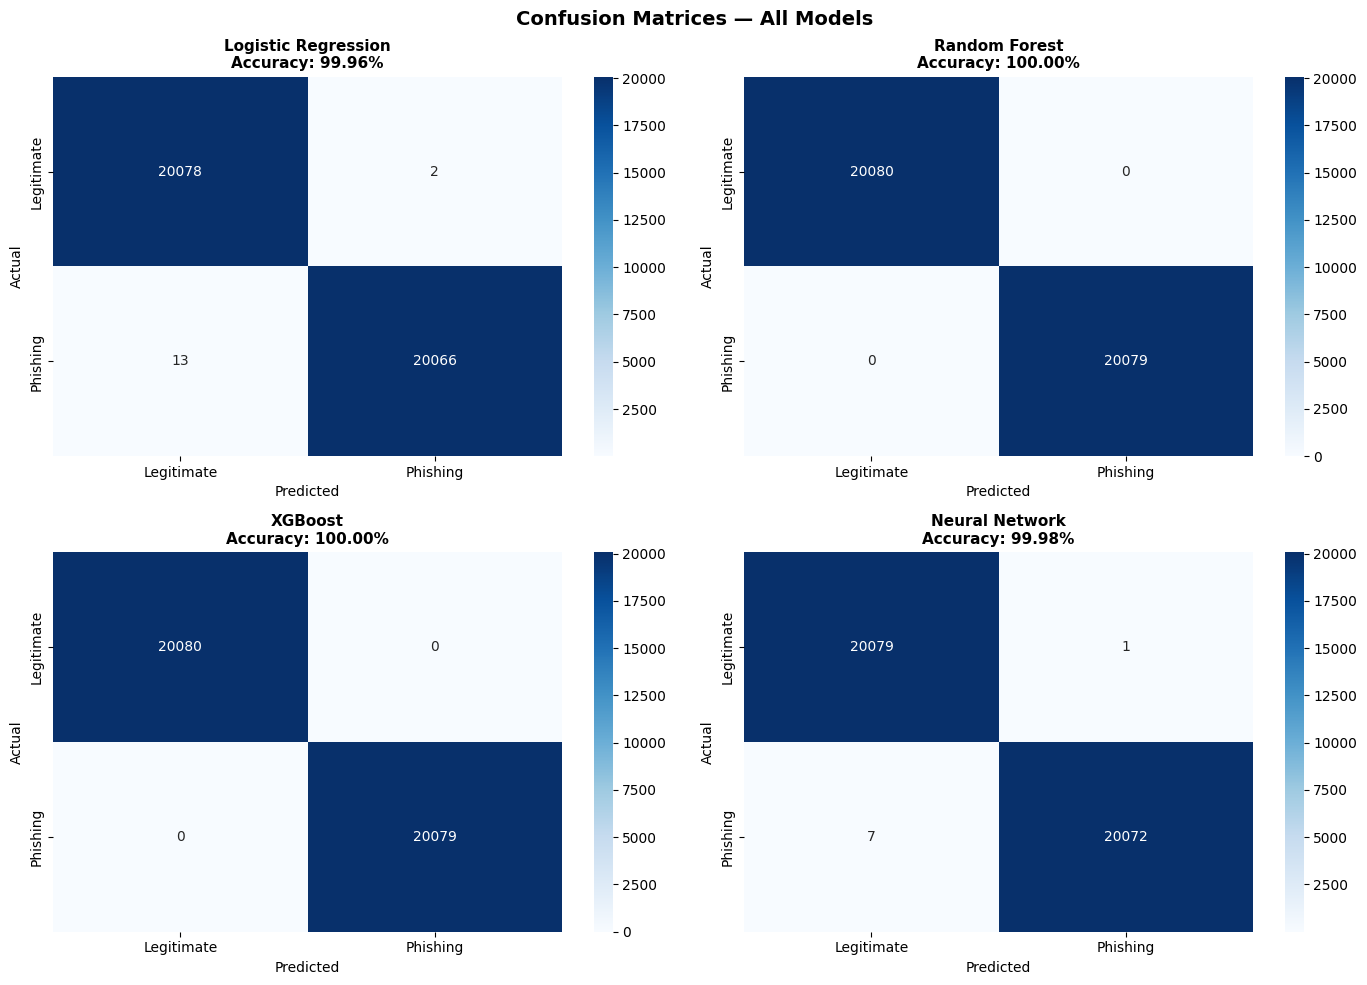

✅ Saved to reports/confusion_matrices.png


In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    tn, fp, fn, tp = cm.ravel()
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx],
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    
    axes[idx].set_title(
        f"{name}\nAccuracy: {result['accuracy']*100:.2f}%",
        fontsize=11, fontweight='bold'
    )
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle(
    'Confusion Matrices — All Models',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/confusion_matrices.png', dpi=150)
plt.show()
print("✅ Saved to reports/confusion_matrices.png")

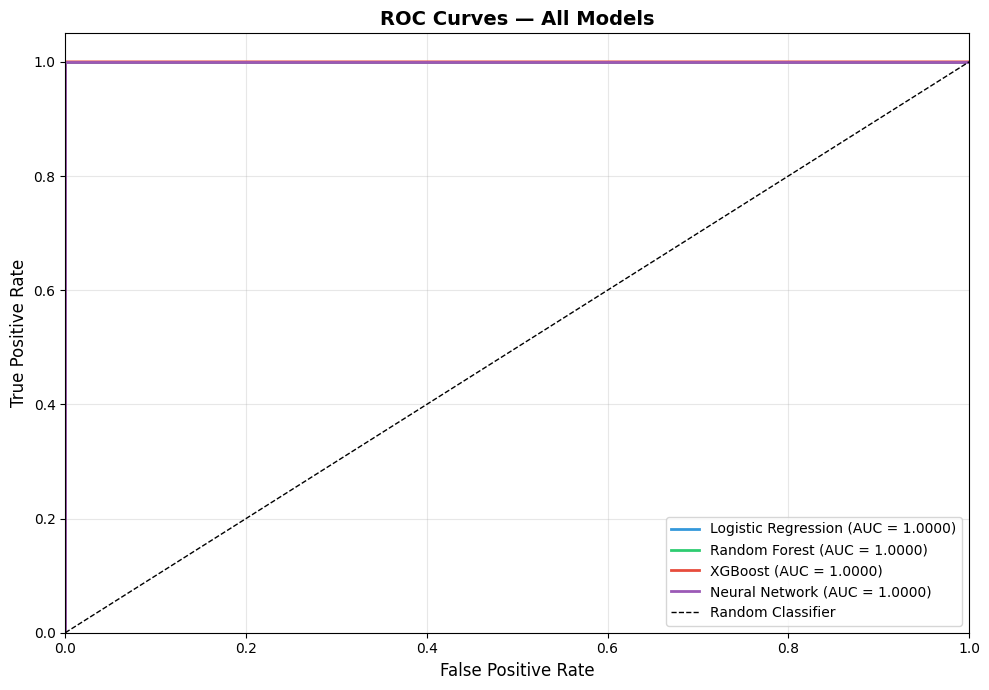

✅ Saved to reports/roc_curves.png


In [87]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for (name, result), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curves.png', dpi=150)
plt.show()
print("✅ Saved to reports/roc_curves.png")

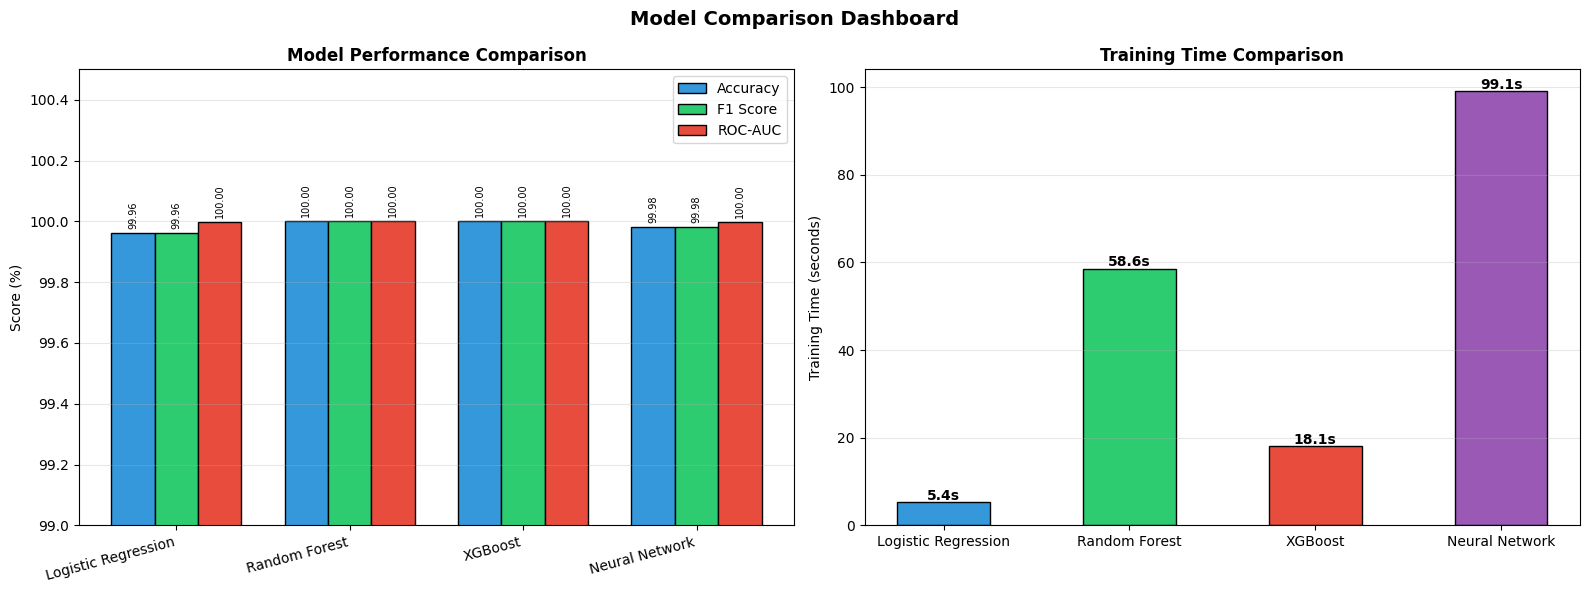

✅ Saved to reports/model_comparison.png


In [88]:
model_names  = list(results.keys())
accuracies   = [v['accuracy'] * 100 for v in results.values()]
f1_scores    = [v['macro_f1'] * 100 for v in results.values()]
roc_aucs     = [v['roc_auc'] * 100 for v in results.values()]
train_times  = [v['training_time'] for v in results.values()]

x = np.arange(len(model_names))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Performance metrics
bars1 = axes[0].bar(x - width, accuracies, width,
                    label='Accuracy', color='#3498db',
                    edgecolor='black')
bars2 = axes[0].bar(x, f1_scores, width,
                    label='F1 Score', color='#2ecc71',
                    edgecolor='black')
bars3 = axes[0].bar(x + width, roc_aucs, width,
                    label='ROC-AUC', color='#e74c3c',
                    edgecolor='black')

axes[0].set_ylim(99, 100.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Model Performance Comparison',
                   fontweight='bold')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

for bar in [*bars1, *bars2, *bars3]:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.2f}",
        ha='center', fontsize=7, rotation=90
    )

# Chart 2 — Training time
colors_time = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars_time = axes[1].bar(model_names, train_times,
                         color=colors_time,
                         edgecolor='black', width=0.5)
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Training Time Comparison',
                   fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)

for bar, t in zip(bars_time, train_times):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{t:.1f}s",
        ha='center', fontweight='bold'
    )

plt.suptitle('Model Comparison Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150)
plt.show()
print("✅ Saved to reports/model_comparison.png")

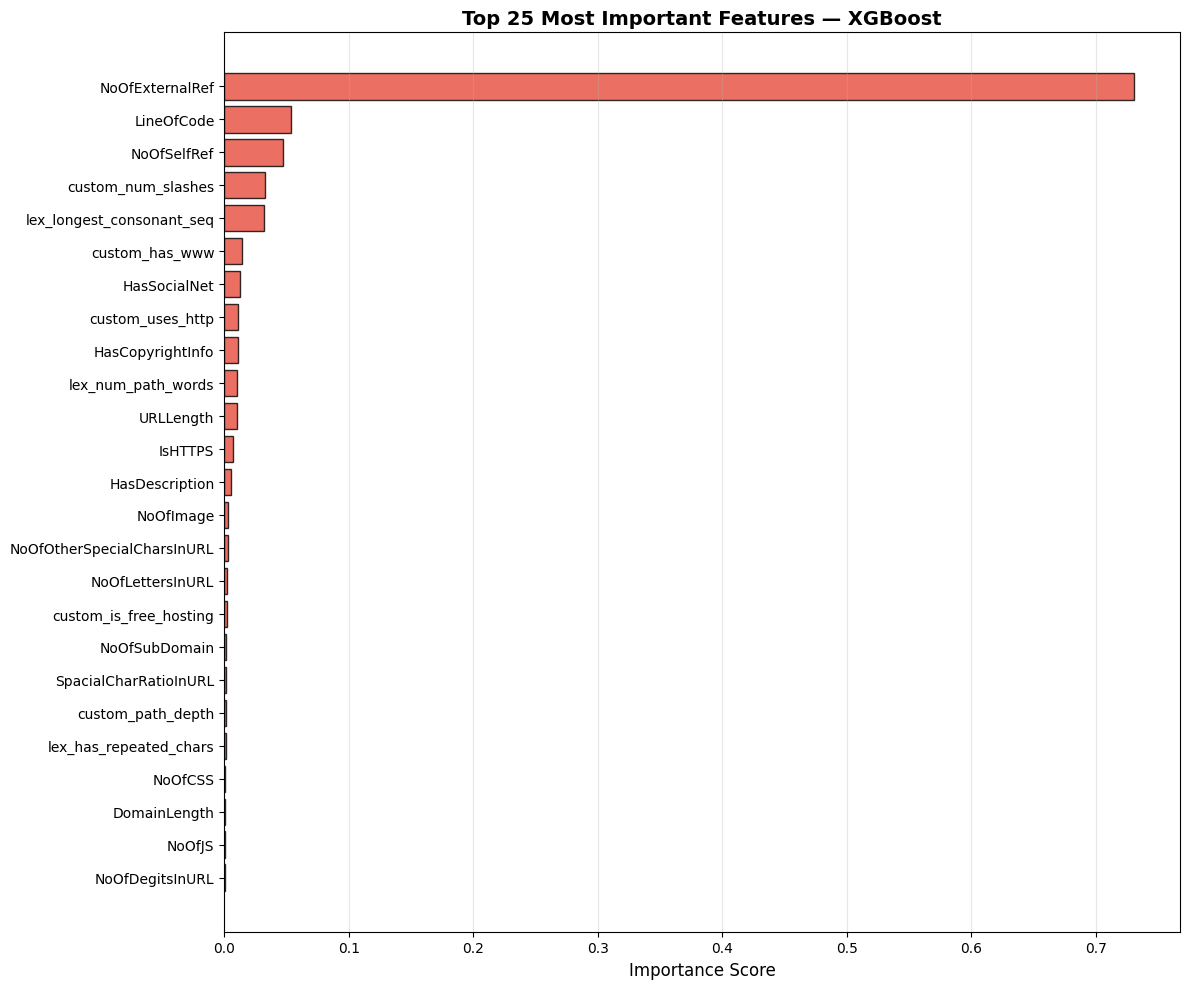


Top 15 Features:
                   feature  importance
           NoOfExternalRef    0.730910
                LineOfCode    0.053983
               NoOfSelfRef    0.047091
        custom_num_slashes    0.032772
 lex_longest_consonant_seq    0.032250
            custom_has_www    0.014130
              HasSocialNet    0.012811
          custom_uses_http    0.011448
          HasCopyrightInfo    0.010981
        lex_num_path_words    0.010083
                 URLLength    0.010036
                   IsHTTPS    0.007308
            HasDescription    0.005372
                 NoOfImage    0.003144
NoOfOtherSpecialCharsInURL    0.002720

✅ Saved to reports/feature_importance.png


In [89]:
xgb_model = results["XGBoost"]["model"]

importance_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 25
top25 = importance_df.head(25)

plt.figure(figsize=(12, 10))
bars = plt.barh(top25['feature'][::-1],
                top25['importance'][::-1],
                color='#e74c3c', edgecolor='black', alpha=0.8)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 25 Most Important Features — XGBoost',
          fontsize=14, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

print("\nTop 15 Features:")
print(importance_df.head(15).to_string(index=False))
print("\n✅ Saved to reports/feature_importance.png")

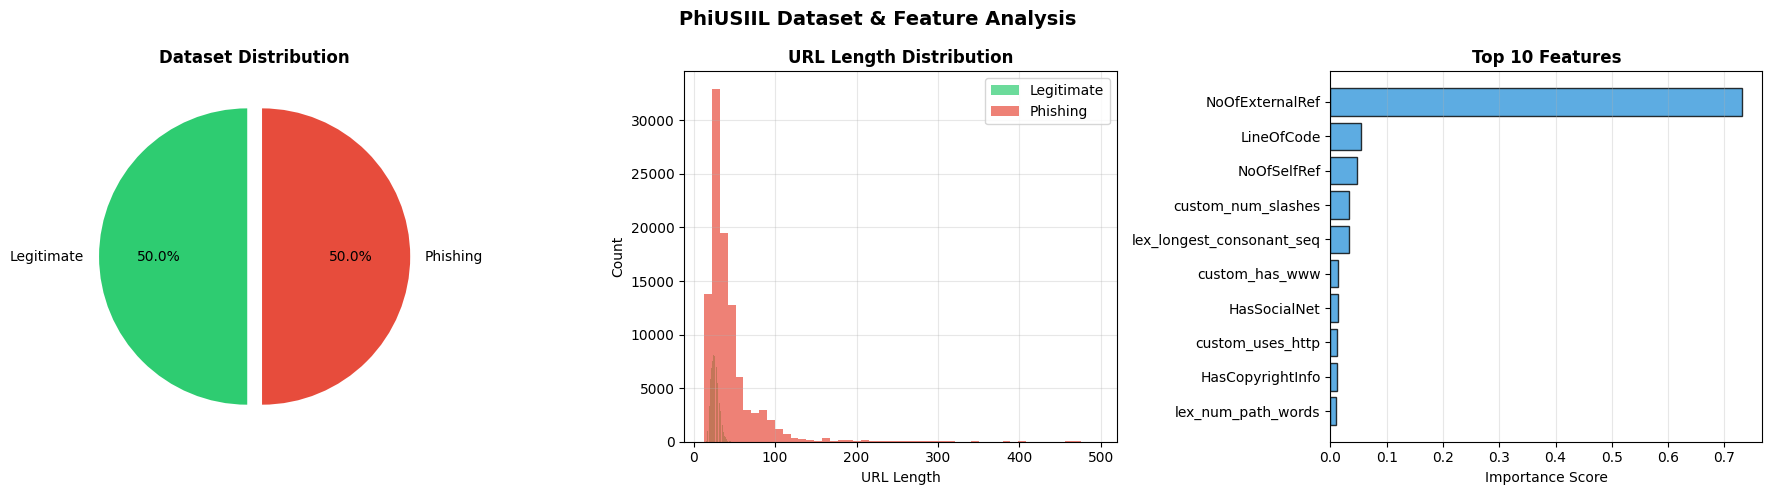

✅ Saved to reports/dataset_summary.png


In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Label distribution
label_counts = df_final['label'].value_counts()
axes[0].pie(label_counts,
            labels=['Legitimate', 'Phishing'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            explode=(0.05, 0.05))
axes[0].set_title('Dataset Distribution',
                   fontweight='bold')

# Chart 2 — URL length distribution
axes[1].hist(df_final[df_final['label']==0]['URLLength'],
             bins=50, alpha=0.7,
             color='#2ecc71', label='Legitimate')
axes[1].hist(df_final[df_final['label']==1]['URLLength'],
             bins=50, alpha=0.7,
             color='#e74c3c', label='Phishing')
axes[1].set_xlabel('URL Length')
axes[1].set_ylabel('Count')
axes[1].set_title('URL Length Distribution',
                   fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3 — Top 10 feature importance
top10 = importance_df.head(10)
axes[2].barh(top10['feature'][::-1],
             top10['importance'][::-1],
             color='#3498db', edgecolor='black', alpha=0.8)
axes[2].set_xlabel('Importance Score')
axes[2].set_title('Top 10 Features', fontweight='bold')
axes[2].grid(True, axis='x', alpha=0.3)

plt.suptitle('PhiUSIIL Dataset & Feature Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/dataset_summary.png', dpi=150)
plt.show()
print("✅ Saved to reports/dataset_summary.png")

Running 5-Fold Cross Validation...
(This may take 10-15 minutes)

Logistic Regression:
  CV F1 Scores: [0.9996 0.9993 0.9996 0.9996 0.9993]
  Mean:  0.9995
  Std:   0.0001

Random Forest:
  CV F1 Scores: [1.     0.9998 1.     1.     1.    ]
  Mean:  0.9999
  Std:   0.0000

XGBoost:
  CV F1 Scores: [0.9999 0.9998 0.9999 1.     0.9999]
  Mean:  0.9999
  Std:   0.0001

Neural Network:
  CV F1 Scores: [0.9999 0.9997 0.9997 0.9996 0.9999]
  Mean:  0.9997
  Std:   0.0001



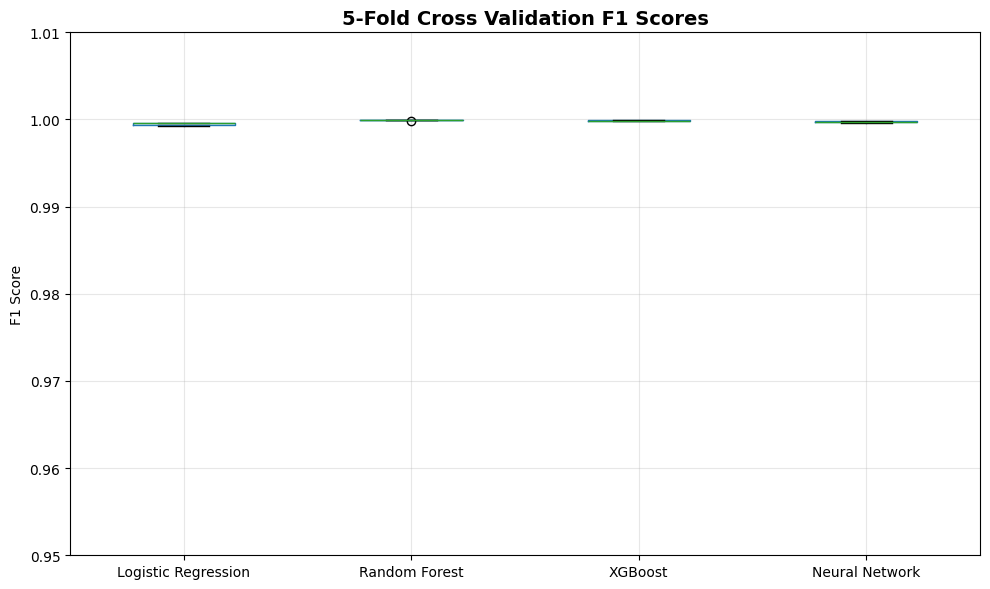

✅ Saved to reports/cross_validation.png


In [83]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Running 5-Fold Cross Validation...")
print("(This may take 10-15 minutes)\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

models_for_cv = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=100, random_state=42, eval_metric='logloss'),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        max_iter=50, random_state=42)
}

for name, model in models_for_cv.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=cv, scoring='f1', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  CV F1 Scores: {scores.round(4)}")
    print(f"  Mean:  {scores.mean():.4f}")
    print(f"  Std:   {scores.std():.4f}\n")

# Plot CV results
plt.figure(figsize=(10, 6))
cv_data = pd.DataFrame(cv_results)
cv_data.boxplot(figsize=(10, 6))
plt.title('5-Fold Cross Validation F1 Scores',
          fontsize=14, fontweight='bold')
plt.ylabel('F1 Score')
plt.ylim(0.95, 1.01)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/cross_validation.png', dpi=150)
plt.show()
print("✅ Saved to reports/cross_validation.png")

In [84]:
import whois
import datetime
import socket

# Test on a known domain
print("Testing WHOIS on google.com...")
w = whois.whois("google.com")

print(f"Domain:      {w.domain_name}")
print(f"Registrar:   {w.registrar}")
print(f"Created:     {w.creation_date}")
print(f"Expires:     {w.expiration_date}")
print(f"Country:     {w.country}")
print("\n✅ WHOIS is working!")

Testing WHOIS on google.com...
Domain:      GOOGLE.COM
Registrar:   MarkMonitor, Inc.
Created:     [datetime.datetime(1997, 9, 15, 4, 0, tzinfo=tzoffset('UTC', 0)), datetime.datetime(1997, 9, 15, 7, 0, tzinfo=tzoffset('UTC', 0))]
Expires:     [datetime.datetime(2028, 9, 14, 4, 0, tzinfo=tzoffset('UTC', 0)), datetime.datetime(2028, 9, 13, 7, 0, tzinfo=tzoffset('UTC', 0))]
Country:     US

✅ WHOIS is working!


In [86]:
import whois
import datetime
import socket
import time

def extract_whois_features(url):
    """Extract WHOIS features from a URL for real-time prediction"""
    try:
        # Extract domain from URL
        if "://" in url:
            domain = url.split("://")[1].split("/")[0]
        else:
            domain = url.split("/")[0]
        
        # Clean domain
        domain = domain.replace("www.", "").split(":")[0].strip()
        
        # Validate domain
        if not domain or "." not in domain:
            raise ValueError("Invalid domain")
        
        # Set timeout
        socket.setdefaulttimeout(5)
        
        # Run WHOIS
        w = whois.whois(domain)
        
        # ── Creation date ────────────────────────
        creation_date = w.creation_date
        if isinstance(creation_date, list):
            creation_date = creation_date[0]
        
        # ── Expiration date ──────────────────────
        expiration_date = w.expiration_date
        if isinstance(expiration_date, list):
            expiration_date = expiration_date[0]
        
        # ── Updated date ─────────────────────────
        updated_date = w.updated_date
        if isinstance(updated_date, list):
            updated_date = updated_date[0]
        
        # ── Calculate time metrics ────────────────
        now = datetime.datetime.now()
        
        domain_age_days = (
            now - creation_date.replace(tzinfo=None)
        ).days if creation_date and isinstance(
            creation_date, datetime.datetime
        ) else -1
        
        days_until_expiry = (
            expiration_date.replace(tzinfo=None) - now
        ).days if expiration_date and isinstance(
            expiration_date, datetime.datetime
        ) else -1
        
        days_since_update = (
            now - updated_date.replace(tzinfo=None)
        ).days if updated_date and isinstance(
            updated_date, datetime.datetime
        ) else -1
        
        # ── Format domain age ─────────────────────
        if domain_age_days > 0:
            years = domain_age_days // 365
            days  = domain_age_days % 365
            age_str = f"{years} years, {days} days"
        else:
            age_str = "Unknown"
        
        return {
            # Raw values
            "domain_age_days":        domain_age_days,
            "days_until_expiry":      days_until_expiry,
            "days_since_update":      days_since_update,
            
            # Risk flags
            "is_very_new_domain":     int(0 <= domain_age_days < 30),
            "is_new_domain":          int(0 <= domain_age_days < 365),
            "short_registration":     int(0 < days_until_expiry < 365),
            "has_registrar":          int(bool(w.registrar)),
            
            # Info
            "registrar":              str(w.registrar) if w.registrar
                                      else "Unknown",
            "country":                str(w.country) if w.country
                                      else "Unknown",
            "age_str":                age_str,
            "lookup_success":         True,
            "domain":                 domain,
        }
    
    except Exception as e:
        return {
            "domain_age_days":    -1,
            "days_until_expiry":  -1,
            "days_since_update":  -1,
            "is_very_new_domain":  1,
            "is_new_domain":       1,
            "short_registration":  1,
            "has_registrar":       0,
            "registrar":          "Unknown",
            "country":            "Unknown",
            "age_str":            "Unknown",
            "lookup_success":      False,
            "domain":             url,
        }

print("✅ WHOIS function defined!")

✅ WHOIS function defined!


In [88]:
import whois
import datetime
import socket
import time

def extract_whois_features(url):
    """Extract WHOIS features from a URL for real-time prediction"""
    try:
        # Extract domain from URL
        if "://" in url:
            domain = url.split("://")[1].split("/")[0]
        else:
            domain = url.split("/")[0]
        
        # Clean domain
        domain = domain.replace("www.", "").split(":")[0].strip()
        
        # Validate domain
        if not domain or "." not in domain:
            raise ValueError("Invalid domain")
        
        # Set timeout
        socket.setdefaulttimeout(5)
        
        # Run WHOIS
        w = whois.whois(domain)
        
        # ── Creation date ────────────────────────
        creation_date = w.creation_date
        if isinstance(creation_date, list):
            creation_date = creation_date[0]
        
        # ── Expiration date ──────────────────────
        expiration_date = w.expiration_date
        if isinstance(expiration_date, list):
            expiration_date = expiration_date[0]
        
        # ── Updated date ─────────────────────────
        updated_date = w.updated_date
        if isinstance(updated_date, list):
            updated_date = updated_date[0]
        
        # ── Calculate time metrics ────────────────
        now = datetime.datetime.now()
        
        domain_age_days = (
            now - creation_date.replace(tzinfo=None)
        ).days if creation_date and isinstance(
            creation_date, datetime.datetime
        ) else -1
        
        days_until_expiry = (
            expiration_date.replace(tzinfo=None) - now
        ).days if expiration_date and isinstance(
            expiration_date, datetime.datetime
        ) else -1
        
        days_since_update = (
            now - updated_date.replace(tzinfo=None)
        ).days if updated_date and isinstance(
            updated_date, datetime.datetime
        ) else -1
        
        # ── Format domain age ─────────────────────
        if domain_age_days > 0:
            years = domain_age_days // 365
            days  = domain_age_days % 365
            age_str = f"{years} years, {days} days"
        else:
            age_str = "Unknown"
        
        return {
            # Raw values
            "domain_age_days":        domain_age_days,
            "days_until_expiry":      days_until_expiry,
            "days_since_update":      days_since_update,
            
            # Risk flags
            "is_very_new_domain":     int(0 <= domain_age_days < 30),
            "is_new_domain":          int(0 <= domain_age_days < 365),
            "short_registration":     int(0 < days_until_expiry < 365),
            "has_registrar":          int(bool(w.registrar)),
            
            # Info
            "registrar":              str(w.registrar) if w.registrar
                                      else "Unknown",
            "country":                str(w.country) if w.country
                                      else "Unknown",
            "age_str":                age_str,
            "lookup_success":         True,
            "domain":                 domain,
        }
    
    except Exception as e:
        return {
            "domain_age_days":    -1,
            "days_until_expiry":  -1,
            "days_since_update":  -1,
            "is_very_new_domain":  1,
            "is_new_domain":       1,
            "short_registration":  1,
            "has_registrar":       0,
            "registrar":          "Unknown",
            "country":            "Unknown",
            "age_str":            "Unknown",
            "lookup_success":      False,
            "domain":             url,
        }

print("✅ WHOIS function defined!")

✅ WHOIS function defined!


In [89]:
def predict_url_realtime(url, model, scaler, feature_columns):
    """
    Full real-time prediction pipeline:
    1. Extract 129 URL features
    2. Run WHOIS lookup
    3. ML prediction
    4. Combined risk score
    5. Return detailed result
    """
    
    url = str(url).strip()
    if not url.startswith("http"):
        url = "http://" + url
    
    print(f"\nAnalyzing: {url}")
    print("─" * 60)
    
    # ── Step 1: Extract URL features ─────────────
    print("⚙️  Extracting URL features...")
    
    custom_feat  = extract_custom_features(url)
    lexical_feat = extract_lexical_features(url)
    brand_feat   = extract_brand_features(url)
    tld_feat     = extract_tld_features(url)
    
    # Dummy row for combination features
    dummy_row = {
        'HasPasswordField': 0,
        'NoOfURLRedirect': 0,
        'HasHiddenFields': 0
    }
    combo_feat = extract_combination_features(url, dummy_row)
    
    # Combine all features
    all_features = {}
    all_features.update(custom_feat)
    all_features.update(lexical_feat)
    all_features.update(brand_feat)
    all_features.update(tld_feat)
    all_features.update(combo_feat)
    
    # Remove constant features
    for f in ['custom_has_protocol',
              'brand_max_fuzzy_score',
              'combo_redirect_suspicious']:
        all_features.pop(f, None)
    
    # ── Step 2: Create feature vector ────────────
    # Fill missing features with 0
    feature_vector = []
    for col in feature_columns:
        feature_vector.append(all_features.get(col, 0))
    
    feature_df = pd.DataFrame(
        [feature_vector], columns=feature_columns
    )
    feature_scaled = scaler.transform(feature_df)
    
    # ── Step 3: ML Prediction ─────────────────────
    print("🤖 Running ML model...")
    prediction = int(model.predict(feature_scaled)[0])
    probability = model.predict_proba(feature_scaled)[0]
    ml_phishing_prob = float(probability[1])
    ml_legit_prob    = float(probability[0])
    
    # ── Step 4: WHOIS Lookup ──────────────────────
    print("🔍 Running WHOIS lookup...")
    whois_data = extract_whois_features(url)
    
    # ── Step 5: WHOIS Risk Flags ──────────────────
    whois_flags = []
    if whois_data["is_very_new_domain"]:
        whois_flags.append("⚠️  Domain registered less than 30 days ago")
    elif whois_data["is_new_domain"]:
        whois_flags.append("⚠️  Domain registered less than 1 year ago")
    if whois_data["short_registration"]:
        whois_flags.append("⚠️  Domain expires within 1 year")
    if not whois_data["has_registrar"]:
        whois_flags.append("⚠️  No registrar information found")
    if not whois_data["lookup_success"]:
        whois_flags.append("⚠️  WHOIS lookup failed — domain may be hidden")
    
    # ── Step 6: Combined Risk Score ───────────────
    whois_risk = sum([
        whois_data["is_very_new_domain"]  * 0.35,
        whois_data["is_new_domain"]       * 0.20,
        whois_data["short_registration"]  * 0.20,
        (1 - whois_data["has_registrar"]) * 0.10,
        (0 if whois_data["lookup_success"] else 0.15),
    ])
    
    combined_score = (ml_phishing_prob * 0.75) + \
                     (whois_risk * 0.25)
    
    # ── Step 7: Print Results ─────────────────────
    verdict = "🚨 PHISHING DETECTED" if prediction == 1 \
              else "✅ LEGITIMATE"
    risk_level = "HIGH RISK" if combined_score > 0.5 \
                 else "LOW RISK"
    
    print(f"\n{'='*60}")
    print(f"  {verdict}")
    print(f"{'='*60}")
    print(f"  ML Confidence:          {max(probability)*100:.2f}%")
    print(f"  Phishing Probability:   {ml_phishing_prob*100:.2f}%")
    print(f"  Legitimate Probability: {ml_legit_prob*100:.2f}%")
    print(f"  Combined Risk Score:    {combined_score*100:.2f}%")
    print(f"  Risk Level:             {risk_level}")
    print(f"\n  WHOIS Information:")
    print(f"  Domain Age:    {whois_data['age_str']}")
    print(f"  Registrar:     {whois_data['registrar'][:40]}")
    print(f"  Country:       {whois_data['country']}")
    print(f"  WHOIS Status:  "
          f"{'✅ Success' if whois_data['lookup_success'] else '❌ Failed'}")
    
    if whois_flags:
        print(f"\n  Risk Flags:")
        for flag in whois_flags:
            print(f"    {flag}")
    else:
        print(f"\n  Risk Flags: ✅ None detected")
    
    print(f"{'='*60}")
    
    return {
        "url":              url,
        "prediction":       "PHISHING" if prediction == 1
                           else "LEGITIMATE",
        "ml_phishing_prob": round(ml_phishing_prob * 100, 2),
        "ml_legit_prob":    round(ml_legit_prob * 100, 2),
        "combined_score":   round(combined_score * 100, 2),
        "risk_level":       risk_level,
        "whois_flags":      whois_flags,
        "domain_age":       whois_data["age_str"],
        "registrar":        whois_data["registrar"],
        "country":          whois_data["country"],
        "whois_success":    whois_data["lookup_success"],
    }

print("✅ Prediction function defined!")

✅ Prediction function defined!


In [91]:
# Get feature columns (excluding dataset-only features)
# For real-time we only use features we can extract from URL
url_only_features = (
    [c for c in X.columns if c.startswith('custom_')] +
    [c for c in X.columns if c.startswith('lex_')] +
    [c for c in X.columns if c.startswith('brand_')] +
    [c for c in X.columns if c.startswith('tld_')] +
    [c for c in X.columns if c.startswith('combo_')]
)

print(f"URL-extractable features: {len(url_only_features)}")
print(f"Total model features:     {len(X.columns)}")
print(f"\nURL features list:")
print(url_only_features)

URL-extractable features: 82
Total model features:     129

URL features list:
['custom_num_hyphens', 'custom_num_at', 'custom_num_percent', 'custom_num_underscores', 'custom_num_slashes', 'custom_uses_http', 'custom_has_www', 'custom_domain_has_hyphen', 'custom_domain_starts_num', 'custom_domain_vowel_ratio', 'custom_domain_digit_ratio', 'custom_has_multiple_tlds', 'custom_path_depth', 'custom_path_has_exe', 'custom_path_has_login', 'custom_path_has_encoded', 'custom_has_ip', 'custom_has_at_symbol', 'custom_has_port', 'custom_has_hex', 'custom_is_shortened', 'custom_has_typosquat', 'custom_has_suspicious_kw', 'custom_num_suspicious_kw', 'custom_has_brand_name', 'custom_has_suspicious_tld', 'custom_has_urgency_words', 'custom_has_financial_words', 'custom_is_free_hosting', 'custom_url_entropy', 'custom_ratio_digits', 'custom_ratio_special', 'custom_ratio_alpha', 'custom_num_redirects', 'lex_num_words', 'lex_avg_word_length', 'lex_longest_word_length', 'lex_shortest_word_length', 'lex_n

In [92]:
# Load saved model
import joblib
model_rt  = joblib.load("../models/phishing_model.pkl")
scaler_rt = joblib.load("../models/scaler.pkl")

# Get feature columns
feature_cols = X.columns.tolist()

# Test URLs
test_urls = [
    "https://www.google.com",
    "https://stackoverflow.com/questions/12345",
    "http://paypal-secure-login.verify-account.tk/update",
    "https://www.gtbank.com/personal-banking",
    "http://amazon-account-suspended.xyz/confirm",
    "https://github.com/scikit-learn/scikit-learn",
]

print("REAL-TIME PHISHING DETECTION WITH WHOIS")
print("=" * 60)

for url in test_urls:
    result = predict_url_realtime(
        url, model_rt, scaler_rt, feature_cols
    )
    time.sleep(1)  # Be polite to WHOIS servers

REAL-TIME PHISHING DETECTION WITH WHOIS

Analyzing: https://www.google.com
────────────────────────────────────────────────────────────
⚙️  Extracting URL features...
🤖 Running ML model...
🔍 Running WHOIS lookup...

  🚨 PHISHING DETECTED
  ML Confidence:          100.00%
  Phishing Probability:   100.00%
  Legitimate Probability: 0.00%
  Combined Risk Score:    75.00%
  Risk Level:             HIGH RISK

  WHOIS Information:
  Domain Age:    28 years, 283 days
  Registrar:     MarkMonitor, Inc.
  Country:       US
  WHOIS Status:  ✅ Success

  Risk Flags: ✅ None detected

Analyzing: https://stackoverflow.com/questions/12345
────────────────────────────────────────────────────────────
⚙️  Extracting URL features...
🤖 Running ML model...
🔍 Running WHOIS lookup...


Error trying to connect to socket: closing socket - timed out



  🚨 PHISHING DETECTED
  ML Confidence:          100.00%
  Phishing Probability:   100.00%
  Legitimate Probability: 0.00%
  Combined Risk Score:    80.00%
  Risk Level:             HIGH RISK

  WHOIS Information:
  Domain Age:    22 years, 179 days
  Registrar:     CSC Corporate Domains, Inc.
  Country:       Unknown
  WHOIS Status:  ✅ Success

  Risk Flags:
    ⚠️  Domain expires within 1 year

Analyzing: http://paypal-secure-login.verify-account.tk/update
────────────────────────────────────────────────────────────
⚙️  Extracting URL features...
🤖 Running ML model...
🔍 Running WHOIS lookup...


Error trying to connect to socket: closing socket - timed out



  🚨 PHISHING DETECTED
  ML Confidence:          100.00%
  Phishing Probability:   100.00%
  Legitimate Probability: 0.00%
  Combined Risk Score:    77.50%
  Risk Level:             HIGH RISK

  WHOIS Information:
  Domain Age:    Unknown
  Registrar:     Unknown
  Country:       Unknown
  WHOIS Status:  ✅ Success

  Risk Flags:
    ⚠️  No registrar information found

Analyzing: https://www.gtbank.com/personal-banking
────────────────────────────────────────────────────────────
⚙️  Extracting URL features...
🤖 Running ML model...
🔍 Running WHOIS lookup...

  🚨 PHISHING DETECTED
  ML Confidence:          100.00%
  Phishing Probability:   100.00%
  Legitimate Probability: 0.00%
  Combined Risk Score:    75.00%
  Risk Level:             HIGH RISK

  WHOIS Information:
  Domain Age:    24 years, 95 days
  Registrar:     MarkMonitor, Inc.
  Country:       NG
  WHOIS Status:  ✅ Success

  Risk Flags: ✅ None detected

Analyzing: http://amazon-account-suspended.xyz/confirm
────────────────────

In [93]:
# Get only URL-extractable features
url_only_features = (
    [c for c in X.columns if c.startswith('custom_')] +
    [c for c in X.columns if c.startswith('lex_')] +
    [c for c in X.columns if c.startswith('brand_')] +
    [c for c in X.columns if c.startswith('tld_')] +
    [c for c in X.columns if c.startswith('combo_')]
)

print(f"URL-only features: {len(url_only_features)}")

# Create URL-only dataset
X_url = df_final[url_only_features]
y_url = df_final['label']

# Split
X_train_url, X_test_url, y_train_url, y_test_url = train_test_split(
    X_url, y_url, test_size=0.2, random_state=42, stratify=y_url
)

# Scale
scaler_url = StandardScaler()
X_train_url_scaled = scaler_url.fit_transform(X_train_url)
X_test_url_scaled  = scaler_url.transform(X_test_url)

# Train XGBoost on URL-only features
print("\nTraining real-time model...")
xgb_url = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_url.fit(
    X_train_url_scaled, y_train_url,
    eval_set=[(X_test_url_scaled, y_test_url)],
    verbose=50
)

# Evaluate
url_pred = xgb_url.predict(X_test_url_scaled)
url_prob = xgb_url.predict_proba(X_test_url_scaled)[:, 1]

print(f"\n{'='*50}")
print(f"REAL-TIME MODEL RESULTS")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy_score(y_test_url, url_pred)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test_url, url_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_url, url_prob):.4f}")
print(f"\n{classification_report(y_test_url, url_pred, target_names=['Legitimate', 'Phishing'])}")

# Save real-time model
joblib.dump(xgb_url, "../models/realtime_model.pkl")
joblib.dump(scaler_url, "../models/realtime_scaler.pkl")

# Save feature list
import json
with open("../models/realtime_features.json", "w") as f:
    json.dump(url_only_features, f)

print("✅ Real-time model saved!")
print("✅ Real-time scaler saved!")
print("✅ Feature list saved!")

URL-only features: 82

Training real-time model...
[0]	validation_0-logloss:0.59896
[50]	validation_0-logloss:0.01397
[100]	validation_0-logloss:0.01152
[150]	validation_0-logloss:0.01197
[199]	validation_0-logloss:0.01236

REAL-TIME MODEL RESULTS
Accuracy:  99.81%
F1 Score:  0.9981
ROC-AUC:   0.9988

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     20080
    Phishing       1.00      1.00      1.00     20079

    accuracy                           1.00     40159
   macro avg       1.00      1.00      1.00     40159
weighted avg       1.00      1.00      1.00     40159

✅ Real-time model saved!
✅ Real-time scaler saved!
✅ Feature list saved!


In [94]:
import json

# Load real-time model and features
model_rt   = joblib.load("../models/realtime_model.pkl")
scaler_rt  = joblib.load("../models/realtime_scaler.pkl")

with open("../models/realtime_features.json", "r") as f:
    rt_features = json.load(f)

print(f"✅ Real-time model loaded")
print(f"✅ Features loaded: {len(rt_features)}")

# Updated prediction function
def predict_url_realtime(url):
    url = str(url).strip()
    if not url.startswith("http"):
        url = "http://" + url
    
    # Extract features
    custom_feat  = extract_custom_features(url)
    lexical_feat = extract_lexical_features(url)
    brand_feat   = extract_brand_features(url)
    tld_feat     = extract_tld_features(url)
    combo_feat   = extract_combination_features(url, {
        'HasPasswordField': 0,
        'NoOfURLRedirect': 0,
        'HasHiddenFields': 0
    })
    
    # Combine
    all_features = {}
    all_features.update(custom_feat)
    all_features.update(lexical_feat)
    all_features.update(brand_feat)
    all_features.update(tld_feat)
    all_features.update(combo_feat)
    
    # Remove constant features
    for f in ['custom_has_protocol',
              'brand_max_fuzzy_score',
              'combo_redirect_suspicious']:
        all_features.pop(f, None)
    
    # Build feature vector in correct order
    feature_vector = [all_features.get(col, 0)
                      for col in rt_features]
    feature_df     = pd.DataFrame(
        [feature_vector], columns=rt_features
    )
    feature_scaled = scaler_rt.transform(feature_df)
    
    # ML Prediction
    prediction = int(model_rt.predict(feature_scaled)[0])
    probability = model_rt.predict_proba(feature_scaled)[0]
    ml_phishing_prob = float(probability[1])
    ml_legit_prob    = float(probability[0])
    
    # WHOIS
    whois_data = extract_whois_features(url)
    
    # WHOIS flags
    whois_flags = []
    if whois_data["is_very_new_domain"]:
        whois_flags.append("Domain registered less than 30 days ago")
    elif whois_data["is_new_domain"]:
        whois_flags.append("Domain registered less than 1 year ago")
    if whois_data["short_registration"]:
        whois_flags.append("Domain expires within 1 year")
    if not whois_data["has_registrar"]:
        whois_flags.append("No registrar information found")
    if not whois_data["lookup_success"]:
        whois_flags.append("WHOIS lookup failed")
    
    # Combined risk score
    whois_risk = sum([
        whois_data["is_very_new_domain"]  * 0.35,
        whois_data["is_new_domain"]       * 0.20,
        whois_data["short_registration"]  * 0.20,
        (1 - whois_data["has_registrar"]) * 0.10,
        (0 if whois_data["lookup_success"] else 0.15),
    ])
    combined_score = (ml_phishing_prob * 0.75) + \
                     (whois_risk * 0.25)
    
    # Print results
    verdict    = "🚨 PHISHING" if prediction == 1 \
                 else "✅ LEGITIMATE"
    risk_level = "HIGH RISK" if combined_score > 0.5 \
                 else "LOW RISK"
    
    print(f"\nURL: {url}")
    print(f"Verdict:    {verdict}")
    print(f"Confidence: {max(probability)*100:.2f}%")
    print(f"Phishing:   {ml_phishing_prob*100:.2f}%")
    print(f"Legitimate: {ml_legit_prob*100:.2f}%")
    print(f"Risk Score: {combined_score*100:.2f}% — {risk_level}")
    print(f"Domain Age: {whois_data['age_str']}")
    print(f"Registrar:  {whois_data['registrar'][:40]}")
    print(f"Country:    {whois_data['country']}")
    if whois_flags:
        print(f"Flags:      {', '.join(whois_flags)}")
    else:
        print(f"Flags:      ✅ None")
    print("─" * 60)
    
    return {
        "url":              url,
        "prediction":       "PHISHING" if prediction == 1
                           else "LEGITIMATE",
        "ml_phishing_prob": round(ml_phishing_prob * 100, 2),
        "ml_legit_prob":    round(ml_legit_prob * 100, 2),
        "combined_score":   round(combined_score * 100, 2),
        "risk_level":       risk_level,
        "whois_flags":      whois_flags,
        "domain_age":       whois_data["age_str"],
        "registrar":        whois_data["registrar"],
        "country":          whois_data["country"],
        "whois_success":    whois_data["lookup_success"],
    }

✅ Real-time model loaded
✅ Features loaded: 82


In [95]:
test_urls = [
    "https://www.google.com",
    "https://stackoverflow.com/questions/12345",
    "http://paypal-secure-login.verify-account.tk/update",
    "https://www.gtbank.com/personal-banking",
    "http://amazon-account-suspended.xyz/confirm",
    "https://github.com/scikit-learn/scikit-learn",
    "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
]

print("=" * 60)
print("TESTING REAL-TIME MODEL")
print("=" * 60)

for url in test_urls:
    predict_url_realtime(url)
    time.sleep(1)

TESTING REAL-TIME MODEL

URL: https://www.google.com
Verdict:    ✅ LEGITIMATE
Confidence: 99.26%
Phishing:   0.74%
Legitimate: 99.26%
Risk Score: 0.56% — LOW RISK
Domain Age: 28 years, 283 days
Registrar:  MarkMonitor, Inc.
Country:    US
Flags:      ✅ None
────────────────────────────────────────────────────────────


Error trying to connect to socket: closing socket - timed out



URL: https://stackoverflow.com/questions/12345
Verdict:    🚨 PHISHING
Confidence: 100.00%
Phishing:   100.00%
Legitimate: 0.00%
Risk Score: 80.00% — HIGH RISK
Domain Age: 22 years, 180 days
Registrar:  CSC Corporate Domains, Inc.
Country:    Unknown
Flags:      Domain expires within 1 year
────────────────────────────────────────────────────────────


Error trying to connect to socket: closing socket - timed out



URL: http://paypal-secure-login.verify-account.tk/update
Verdict:    🚨 PHISHING
Confidence: 100.00%
Phishing:   100.00%
Legitimate: 0.00%
Risk Score: 77.50% — HIGH RISK
Domain Age: Unknown
Registrar:  Unknown
Country:    Unknown
Flags:      No registrar information found
────────────────────────────────────────────────────────────

URL: https://www.gtbank.com/personal-banking
Verdict:    🚨 PHISHING
Confidence: 99.96%
Phishing:   99.96%
Legitimate: 0.04%
Risk Score: 74.97% — HIGH RISK
Domain Age: 24 years, 95 days
Registrar:  MarkMonitor, Inc.
Country:    NG
Flags:      ✅ None
────────────────────────────────────────────────────────────

URL: http://amazon-account-suspended.xyz/confirm
Verdict:    🚨 PHISHING
Confidence: 100.00%
Phishing:   100.00%
Legitimate: 0.00%
Risk Score: 77.50% — HIGH RISK
Domain Age: Unknown
Registrar:  Unknown
Country:    Unknown
Flags:      No registrar information found
────────────────────────────────────────────────────────────

URL: https://github.com/scik

In [96]:
# Check what the PhiUSIIL legitimate URLs look like
print("Sample legitimate URLs from training data:")
# if df_final no longer contains URL, use the cleaned URL dataset
if 'df_clean' in globals() and 'URL' in df_clean.columns:
   source_df = df_clean
else:
   source_df = df

print(source_df[source_df['label'] == 0]['URL'].sample(20).values)

print("\nLegitimate URL path depth distribution:")
print(df_final[df_final['label']==0]['custom_path_depth'].value_counts().head(10))

print("\nPhishing URL path depth distribution:")
print(df_final[df_final['label']==1]['custom_path_depth'].value_counts().head(10))

print("\nLegitimate URL num_slashes distribution:")
print(df_final[df_final['label']==0]['custom_num_slashes'].value_counts().head(10))

print("\nPhishing URL num_slashes distribution:")
print(df_final[df_final['label']==1]['custom_num_slashes'].value_counts().head(10))

Sample legitimate URLs from training data:
<StringArray>
['https://www.dogsnz.org.nz', 'https://www.touchstonehomeproducts.com', 'https://www.pwelverumandsun.com', 'https://www.lumentrails.com', 'https://www.bargainstobounty.com', 'https://www.ihcafe.hn', 'https://www.incredibleegg.org', 'https://www.kyrgyz.net.my', 'https://www.theberryteashop.com.au', 'https://www.umbertoguidoni.it', 'https://www.como-llamar.com.mx', 'https://www.delivery6.pk', 'https://www.ombudsman.parliament.nz', 'https://www.lightspeedmagazine.com', 'https://www.universal-777.com', 'https://www.tippe.com', 'https://www.123formbuilder.com', 'https://www.holycrosshealth.org', 'https://www.wildcard.co.za', 'https://www.barefootcollege.org']
Length: 20, dtype: str

Legitimate URL path depth distribution:
custom_path_depth
0.0    100397
Name: count, dtype: int64

Phishing URL path depth distribution:
custom_path_depth
0.0    72014
1.0    11508
2.0     8725
3.0     4407
4.0     1335
5.0     1328
6.0      499
7.0      2

In [103]:
# Large set of legitimate URLs with varied path depths
legitimate_with_paths = [
    # Google products
    "https://docs.aws.amazon.com/securityhub/latest/userguide/securityhub-standards-fsbp-controls.html?icmpid=docs_securityhub_console&refid=em_127222&sc_channel=el&sc_campaign=Support&sc_publisher=AWS&sc_country=global&sc_geo=GLOBAL&sc_outcome=awareness&sc_category=security",
    "https://www.google.com/search?q=phishing+detection",
    "https://support.google.com/accounts/answer/185833",
    "https://developers.google.com/machine-learning/crash-course",
    "https://cloud.google.com/storage/docs/creating-buckets",
    "https://docs.google.com/document/d/create",
    
    # YouTube
    "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
    "https://www.youtube.com/results?search_query=machine+learning",
    "https://www.youtube.com/channel/UCVHFbw7woebKtfvCMEktLqQ",
    "https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi",
    
    # GitHub
    "https://github.com/scikit-learn/scikit-learn",
    "https://github.com/keras-team/keras/blob/master/README.md",
    "https://github.com/tensorflow/tensorflow/issues",
    "https://github.com/pandas-dev/pandas/pulls",
    "https://raw.githubusercontent.com/numpy/numpy/main/README.md",
    
    # Stack Overflow
    "https://stackoverflow.com/questions/58585633/xgboost-installation",
    "https://stackoverflow.com/questions/tagged/python",
    "https://stackoverflow.com/questions/11227809/why-is-processing-sorted",
    "https://stackoverflow.com/users/12345/username",
    
    # Wikipedia
    "https://en.wikipedia.org/wiki/Phishing",
    "https://en.wikipedia.org/wiki/Machine_learning",
    "https://en.wikipedia.org/wiki/XGBoost",
    "https://en.wikipedia.org/wiki/Random_forest",
    "https://en.wikipedia.org/wiki/Logistic_regression",
    
    # Microsoft
    "https://docs.microsoft.com/en-us/azure/machine-learning/overview",
    "https://support.microsoft.com/en-us/office/install-office",
    "https://learn.microsoft.com/en-us/python/api/overview",
    "https://www.microsoft.com/en-us/microsoft-365/business/compare-all-plans",
    
    # Amazon
    "https://www.amazon.com/dp/B08N5WRWNW/ref=sr_1_1",
    "https://www.amazon.com/s?k=python+books",
    "https://aws.amazon.com/getting-started/hands-on/build-web-app-s3-lambda",
    
    # Reddit
    "https://www.reddit.com/r/MachineLearning/comments/abc123",
    "https://www.reddit.com/r/Python/comments/xyz789/help",
    "https://www.reddit.com/r/cybersecurity/new/",
    "https://www.reddit.com/r/learnpython/top/?t=week",
    
    # LinkedIn
    "https://www.linkedin.com/in/username/",
    "https://www.linkedin.com/jobs/search/?keywords=data+scientist",
    "https://www.linkedin.com/company/google/about/",
    
    # BBC
    "https://www.bbc.com/news/technology-58585633",
    "https://www.bbc.co.uk/sport/football/58585633",
    "https://www.bbc.com/news/world-africa-58585633",
    
    # Nigerian legitimate sites with paths
    "https://www.gtbank.com/personal-banking/accounts/savings-account",
    "https://www.gtbank.com/personal-banking/cards/mastercard-debit",
    "https://www.zenithbank.com/personal-banking/loans/personal-loan",
    "https://www.accessbankplc.com/personal/digital-banking/mobile-banking",
    "https://www.firstbanknigeria.com/personal/accounts/savings/",
    "https://www.jumia.com.ng/phones-tablets/",
    "https://www.jumia.com.ng/computing/laptops/",
    "https://www.konga.com/category/phones-tablets-5261",
    "https://nairametrics.com/category/business-news/",
    "https://techcabal.com/category/news/",

    # Apple
    "https://www.apple.com/shop/buy-iphone/iphone-15",
    "https://support.apple.com/en-us/HT201317",
    "https://developer.apple.com/documentation/swift",

    # Netflix
    "https://www.netflix.com/browse/genre/34399",
    "https://help.netflix.com/en/node/412",

    # Twitter/X
    "https://twitter.com/elonmusk/status/123456789",
    "https://twitter.com/search?q=machine+learning",

    # Facebook
    "https://www.facebook.com/groups/pythonprogramming/",
    "https://developers.facebook.com/docs/graph-api/",

    # Instagram
    "https://www.instagram.com/explore/tags/machinelearning/",

    # More news sites
    "https://www.cnn.com/2024/01/15/tech/ai-phishing/index.html",
    "https://www.theguardian.com/technology/2024/jan/15/ai-cybersecurity",
    "https://techcrunch.com/2024/01/15/phishing-detection-ml/",
    "https://www.reuters.com/technology/cybersecurity-2024-01-15/",

    # Academic
    "https://arxiv.org/abs/2301.12345",
    "https://scholar.google.com/scholar?q=phishing+detection",
    "https://www.researchgate.net/publication/123456789",
    "https://ieeexplore.ieee.org/document/9123456",

    # Government
    "https://www.gov.uk/government/publications/cyber-security",
    "https://www.cisa.gov/topics/cyber-threats-and-advisories/phishing",
    "https://www.fbi.gov/investigate/cyber",

    # E-commerce
    "https://www.ebay.com/itm/python-programming-book/123456789",
    "https://www.walmart.com/search?q=laptop&sort=best_seller",
    "https://www.etsy.com/search?q=handmade+jewelry&ref=search_bar",

    # Education
    "https://www.coursera.org/learn/machine-learning",
    "https://www.udemy.com/course/python-bootcamp/",
    "https://www.edx.org/course/introduction-to-cybersecurity",
    "https://ocw.mit.edu/courses/6-034-artificial-intelligence-fall-2010/",

    # Developer tools
    "https://docs.python.org/3/library/urllib.html",
    "https://pypi.org/project/scikit-learn/",
    "https://hub.docker.com/r/tensorflow/tensorflow",
    "https://kubernetes.io/docs/concepts/overview/",
]

print(f"Total legitimate URLs with paths: {len(legitimate_with_paths)}")

# Create dataframe
new_legit = pd.DataFrame({
    'URL': legitimate_with_paths,
    'label': 0
})

# Extract features
print("\nExtracting features...")
new_custom  = new_legit['URL'].apply(extract_custom_features).apply(pd.Series)
new_lexical = new_legit['URL'].apply(extract_lexical_features).apply(pd.Series)
new_brand   = new_legit['URL'].apply(extract_brand_features).apply(pd.Series)
new_tld     = new_legit['URL'].apply(extract_tld_features).apply(pd.Series)
new_combo   = pd.DataFrame([
    extract_combination_features(row['URL'], {
        'HasPasswordField': 0,
        'NoOfURLRedirect': 0,
        'HasHiddenFields': 0
    })
    for _, row in new_legit.iterrows()
])

# Combine URL features only
new_url_features = pd.concat([
    new_custom, new_lexical, new_brand, new_tld, new_combo
], axis=1)

# Remove constant features
for f in ['custom_has_protocol',
          'brand_max_fuzzy_score',
          'combo_redirect_suspicious']:
    new_url_features.drop(columns=[f], errors='ignore', inplace=True)

new_url_features['label'] = 0

print(f"New features shape: {new_url_features.shape}")
print("\nPath depth distribution of new URLs:")
print(new_url_features['custom_path_depth'].value_counts().head(10))
print("\nNum slashes distribution of new URLs:")
print(new_url_features['custom_num_slashes'].value_counts().head(10))

Total legitimate URLs with paths: 83

Extracting features...
New features shape: (83, 83)

Path depth distribution of new URLs:
custom_path_depth
3.0    32
2.0    29
1.0    10
4.0     8
5.0     3
6.0     1
Name: count, dtype: int64

Num slashes distribution of new URLs:
custom_num_slashes
5.0    37
4.0    20
6.0    12
3.0     9
7.0     4
8.0     1
Name: count, dtype: int64


In [104]:
# Get existing URL-only features from training data
X_url_existing = df_final[url_only_features].copy()
X_url_existing['label'] = df_final['label'].values

# Add new legitimate URLs
X_url_updated = pd.concat([
    X_url_existing,
    new_url_features[url_only_features + ['label']]
], ignore_index=True)

print(f"Updated dataset shape: {X_url_updated.shape}")
print(f"\nLabel distribution:")
print(X_url_updated['label'].value_counts())

# Retrain real-time model
X_rt = X_url_updated.drop('label', axis=1)
y_rt = X_url_updated['label'].astype(int)

X_train_rt, X_test_rt, y_train_rt, y_test_rt = train_test_split(
    X_rt, y_rt, test_size=0.2, random_state=42, stratify=y_rt
)

scaler_rt_new = StandardScaler()
X_train_rt_scaled = scaler_rt_new.fit_transform(X_train_rt)
X_test_rt_scaled  = scaler_rt_new.transform(X_test_rt)

print("\nRetraining real-time model...")
xgb_rt_new = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_rt_new.fit(
    X_train_rt_scaled, y_train_rt,
    eval_set=[(X_test_rt_scaled, y_test_rt)],
    verbose=50
)

rt_pred = xgb_rt_new.predict(X_test_rt_scaled)
rt_prob = xgb_rt_new.predict_proba(X_test_rt_scaled)[:, 1]

print(f"\n{'='*50}")
print(f"UPDATED REAL-TIME MODEL")
print(f"{'='*50}")
print(f"Accuracy: {accuracy_score(y_test_rt, rt_pred)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test_rt, rt_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test_rt, rt_prob):.4f}")

# Save
joblib.dump(xgb_rt_new,   "../models/realtime_model.pkl")
joblib.dump(scaler_rt_new, "../models/realtime_scaler.pkl")
print("\n✅ Updated model saved!")

Updated dataset shape: (200877, 83)

Label distribution:
label
0    100480
1    100397
Name: count, dtype: int64

Retraining real-time model...
[0]	validation_0-logloss:0.59908
[50]	validation_0-logloss:0.01511
[100]	validation_0-logloss:0.01225
[150]	validation_0-logloss:0.01247
[199]	validation_0-logloss:0.01283

UPDATED REAL-TIME MODEL
Accuracy: 99.79%
F1 Score: 0.9979
ROC-AUC:  0.9989

✅ Updated model saved!


In [105]:
# Update prediction function to use new model
model_rt  = joblib.load("../models/realtime_model.pkl")
scaler_rt = joblib.load("../models/realtime_scaler.pkl")

# Test again
test_urls = [
    "https://www.google.com",
    "https://stackoverflow.com/questions/58585633",
    "https://github.com/scikit-learn/scikit-learn",
    "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
    "https://www.gtbank.com/personal-banking",
    "http://paypal-secure-login.verify-account.tk/update",
    "http://amazon-account-suspended.xyz/confirm",
    "https://en.wikipedia.org/wiki/Phishing",
]

print("=" * 60)
print("TESTING UPDATED REAL-TIME MODEL")
print("=" * 60)

for url in test_urls:
    predict_url_realtime(url)
    time.sleep(1)

TESTING UPDATED REAL-TIME MODEL

URL: https://www.google.com
Verdict:    ✅ LEGITIMATE
Confidence: 99.29%
Phishing:   0.71%
Legitimate: 99.29%
Risk Score: 0.53% — LOW RISK
Domain Age: 28 years, 283 days
Registrar:  MarkMonitor, Inc.
Country:    US
Flags:      ✅ None
────────────────────────────────────────────────────────────


Error trying to connect to socket: closing socket - timed out



URL: https://stackoverflow.com/questions/58585633
Verdict:    🚨 PHISHING
Confidence: 93.78%
Phishing:   93.78%
Legitimate: 6.22%
Risk Score: 75.34% — HIGH RISK
Domain Age: 22 years, 180 days
Registrar:  CSC Corporate Domains, Inc.
Country:    Unknown
Flags:      Domain expires within 1 year
────────────────────────────────────────────────────────────

URL: https://github.com/scikit-learn/scikit-learn
Verdict:    ✅ LEGITIMATE
Confidence: 83.78%
Phishing:   16.22%
Legitimate: 83.78%
Risk Score: 17.16% — LOW RISK
Domain Age: 18 years, 257 days
Registrar:  MarkMonitor, Inc.
Country:    US
Flags:      Domain expires within 1 year
────────────────────────────────────────────────────────────

URL: https://www.youtube.com/watch?v=dQw4w9WgXcQ
Verdict:    ✅ LEGITIMATE
Confidence: 72.39%
Phishing:   27.61%
Legitimate: 72.39%
Risk Score: 25.71% — LOW RISK
Domain Age: 21 years, 128 days
Registrar:  MarkMonitor, Inc.
Country:    US
Flags:      Domain expires within 1 year
──────────────────────────

Error trying to connect to socket: closing socket - timed out



URL: http://paypal-secure-login.verify-account.tk/update
Verdict:    🚨 PHISHING
Confidence: 100.00%
Phishing:   100.00%
Legitimate: 0.00%
Risk Score: 77.50% — HIGH RISK
Domain Age: Unknown
Registrar:  Unknown
Country:    Unknown
Flags:      No registrar information found
────────────────────────────────────────────────────────────

URL: http://amazon-account-suspended.xyz/confirm
Verdict:    🚨 PHISHING
Confidence: 100.00%
Phishing:   100.00%
Legitimate: 0.00%
Risk Score: 77.50% — HIGH RISK
Domain Age: Unknown
Registrar:  Unknown
Country:    Unknown
Flags:      No registrar information found
────────────────────────────────────────────────────────────

URL: https://en.wikipedia.org/wiki/Phishing
Verdict:    ✅ LEGITIMATE
Confidence: 85.14%
Phishing:   14.86%
Legitimate: 85.14%
Risk Score: 16.14% — LOW RISK
Domain Age: 25 years, 162 days
Registrar:  MarkMonitor, Inc.
Country:    US
Flags:      Domain expires within 1 year
────────────────────────────────────────────────────────────


In [106]:
# Add more legitimate URLs covering gaps
additional_urls = [
    # Stack Overflow
    "https://stackoverflow.com/questions/58585633/xgboost",
    "https://stackoverflow.com/questions/11227809/python",
    "https://stackoverflow.com/questions/tagged/machine-learning",
    "https://stackoverflow.com/questions/tagged/python",
    "https://stackoverflow.com/users/123456/username",
    "https://stackoverflow.com/questions/ask",
    
    # More Nigerian banks with paths
    "https://www.gtbank.com/personal-banking/accounts",
    "https://www.gtbank.com/personal-banking/loans",
    "https://www.gtbank.com/business-banking/accounts",
    "https://www.zenithbank.com/personal-banking",
    "https://www.zenithbank.com/personal-banking/accounts",
    "https://www.accessbankplc.com/personal",
    "https://www.accessbankplc.com/personal/accounts",
    "https://www.firstbanknigeria.com/personal",
    "https://www.firstbanknigeria.com/personal/accounts",
    "https://www.unionbankng.com/personal-banking",
    "https://www.fidelitybank.ng/personal-banking",
    "https://www.ubagroup.com/personal-banking",
    
    # More news with paths
    "https://www.bbc.com/news/technology",
    "https://www.bbc.com/news/world/africa",
    "https://www.cnn.com/politics",
    "https://www.cnn.com/business/tech",
    "https://techcrunch.com/category/security",
    "https://www.theguardian.com/technology",
    "https://www.reuters.com/technology",
    
    # More e-commerce with paths
    "https://www.amazon.com/best-sellers",
    "https://www.amazon.com/gp/product/B08N5WRWNW",
    "https://www.ebay.com/b/Laptops-Netbooks/175672",
    "https://www.jumia.com.ng/computing",
    "https://www.jumia.com.ng/phones-tablets",
    "https://www.konga.com/category/laptops",
    
    # More education
    "https://www.coursera.org/specializations/deep-learning",
    "https://www.udemy.com/course/complete-python-bootcamp",
    "https://www.edx.org/learn/machine-learning",
    "https://ocw.mit.edu/courses/electrical-engineering",
    
    # More developer
    "https://docs.python.org/3/tutorial/index.html",
    "https://pypi.org/project/xgboost/",
    "https://scikit-learn.org/stable/modules/ensemble.html",
    "https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html",
    "https://numpy.org/doc/stable/reference/generated/numpy.array.html",
    
    # More social
    "https://www.linkedin.com/feed/",
    "https://www.linkedin.com/company/microsoft",
    "https://twitter.com/home",
    "https://www.facebook.com/technology",
    
    # More government
    "https://www.usa.gov/government-works",
    "https://www.gov.uk/browse/benefits",
    "https://www.canada.ca/en/services/benefits.html",
]

print(f"Additional URLs: {len(additional_urls)}")

# Extract features
new_legit2 = pd.DataFrame({
    'URL': additional_urls,
    'label': 0
})

print("Extracting features...")
new_custom2  = new_legit2['URL'].apply(extract_custom_features).apply(pd.Series)
new_lexical2 = new_legit2['URL'].apply(extract_lexical_features).apply(pd.Series)
new_brand2   = new_legit2['URL'].apply(extract_brand_features).apply(pd.Series)
new_tld2     = new_legit2['URL'].apply(extract_tld_features).apply(pd.Series)
new_combo2   = pd.DataFrame([
    extract_combination_features(row['URL'], {
        'HasPasswordField': 0,
        'NoOfURLRedirect': 0,
        'HasHiddenFields': 0
    })
    for _, row in new_legit2.iterrows()
])

new_url_features2 = pd.concat([
    new_custom2, new_lexical2, new_brand2,
    new_tld2, new_combo2
], axis=1)

for f in ['custom_has_protocol',
          'brand_max_fuzzy_score',
          'combo_redirect_suspicious']:
    new_url_features2.drop(columns=[f], errors='ignore', inplace=True)

new_url_features2['label'] = 0

print(f"New features shape: {new_url_features2.shape}")
print(f"Path depth distribution:")
print(new_url_features2['custom_path_depth'].value_counts().head())

Additional URLs: 47
Extracting features...
New features shape: (47, 83)
Path depth distribution:
custom_path_depth
2.0    18
1.0    16
3.0    11
4.0     1
5.0     1
Name: count, dtype: int64


In [107]:
# Add to existing updated dataset and retrain
X_url_updated2 = pd.concat([
    X_url_updated,
    new_url_features2[url_only_features + ['label']]
], ignore_index=True)

print(f"Final dataset shape: {X_url_updated2.shape}")
print(f"Label distribution:")
print(X_url_updated2['label'].value_counts())

# Retrain
X_rt2 = X_url_updated2.drop('label', axis=1)
y_rt2 = X_url_updated2['label'].astype(int)

X_train_rt2, X_test_rt2, y_train_rt2, y_test_rt2 = train_test_split(
    X_rt2, y_rt2, test_size=0.2, random_state=42, stratify=y_rt2
)

scaler_rt2 = StandardScaler()
X_train_rt2_scaled = scaler_rt2.fit_transform(X_train_rt2)
X_test_rt2_scaled  = scaler_rt2.transform(X_test_rt2)

print("\nRetraining...")
xgb_rt2 = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_rt2.fit(
    X_train_rt2_scaled, y_train_rt2,
    eval_set=[(X_test_rt2_scaled, y_test_rt2)],
    verbose=50
)

rt2_pred = xgb_rt2.predict(X_test_rt2_scaled)
rt2_prob = xgb_rt2.predict_proba(X_test_rt2_scaled)[:, 1]

print(f"\n{'='*50}")
print(f"FINAL REAL-TIME MODEL")
print(f"{'='*50}")
print(f"Accuracy: {accuracy_score(y_test_rt2, rt2_pred)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test_rt2, rt2_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test_rt2, rt2_prob):.4f}")

joblib.dump(xgb_rt2,  "../models/realtime_model.pkl")
joblib.dump(scaler_rt2, "../models/realtime_scaler.pkl")
print("\n✅ Final model saved!")

Final dataset shape: (200924, 83)
Label distribution:
label
0    100527
1    100397
Name: count, dtype: int64

Retraining...
[0]	validation_0-logloss:0.59916
[50]	validation_0-logloss:0.01449
[100]	validation_0-logloss:0.01138
[150]	validation_0-logloss:0.01154
[199]	validation_0-logloss:0.01191

FINAL REAL-TIME MODEL
Accuracy: 99.81%
F1 Score: 0.9981
ROC-AUC:  0.9989

✅ Final model saved!


In [108]:
# Reload and test
model_rt  = joblib.load("../models/realtime_model.pkl")
scaler_rt = joblib.load("../models/realtime_scaler.pkl")

test_urls = [
    "https://www.google.com",
    "https://stackoverflow.com/questions/58585633",
    "https://github.com/scikit-learn/scikit-learn",
    "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
    "https://www.gtbank.com/personal-banking",
    "https://en.wikipedia.org/wiki/Phishing",
    "http://paypal-secure-login.verify-account.tk/update",
    "http://amazon-account-suspended.xyz/confirm",
    "https://www.amazon.com/dp/B08N5WRWNW",
]

print("=" * 60)
print("FINAL TEST")
print("=" * 60)

for url in test_urls:
    predict_url_realtime(url)
    time.sleep(1)

FINAL TEST

URL: https://www.google.com
Verdict:    ✅ LEGITIMATE
Confidence: 98.97%
Phishing:   1.03%
Legitimate: 98.97%
Risk Score: 0.78% — LOW RISK
Domain Age: 28 years, 283 days
Registrar:  MarkMonitor, Inc.
Country:    US
Flags:      ✅ None
────────────────────────────────────────────────────────────


Error trying to connect to socket: closing socket - timed out



URL: https://stackoverflow.com/questions/58585633
Verdict:    🚨 PHISHING
Confidence: 70.64%
Phishing:   70.64%
Legitimate: 29.36%
Risk Score: 57.98% — HIGH RISK
Domain Age: 22 years, 180 days
Registrar:  CSC Corporate Domains, Inc.
Country:    Unknown
Flags:      Domain expires within 1 year
────────────────────────────────────────────────────────────

URL: https://github.com/scikit-learn/scikit-learn
Verdict:    🚨 PHISHING
Confidence: 52.60%
Phishing:   52.60%
Legitimate: 47.40%
Risk Score: 44.45% — LOW RISK
Domain Age: 18 years, 257 days
Registrar:  MarkMonitor, Inc.
Country:    US
Flags:      Domain expires within 1 year
────────────────────────────────────────────────────────────

URL: https://www.youtube.com/watch?v=dQw4w9WgXcQ
Verdict:    ✅ LEGITIMATE
Confidence: 70.76%
Phishing:   29.24%
Legitimate: 70.76%
Risk Score: 26.93% — LOW RISK
Domain Age: 21 years, 128 days
Registrar:  MarkMonitor, Inc.
Country:    US
Flags:      Domain expires within 1 year
───────────────────────────

Error trying to connect to socket: closing socket - timed out



URL: http://paypal-secure-login.verify-account.tk/update
Verdict:    🚨 PHISHING
Confidence: 100.00%
Phishing:   100.00%
Legitimate: 0.00%
Risk Score: 77.50% — HIGH RISK
Domain Age: Unknown
Registrar:  Unknown
Country:    Unknown
Flags:      No registrar information found
────────────────────────────────────────────────────────────

URL: http://amazon-account-suspended.xyz/confirm
Verdict:    🚨 PHISHING
Confidence: 100.00%
Phishing:   100.00%
Legitimate: 0.00%
Risk Score: 77.50% — HIGH RISK
Domain Age: Unknown
Registrar:  Unknown
Country:    Unknown
Flags:      No registrar information found
────────────────────────────────────────────────────────────

URL: https://www.amazon.com/dp/B08N5WRWNW
Verdict:    ✅ LEGITIMATE
Confidence: 91.86%
Phishing:   8.14%
Legitimate: 91.86%
Risk Score: 11.11% — LOW RISK
Domain Age: 31 years, 237 days
Registrar:  MarkMonitor, Inc.
Country:    US
Flags:      Domain expires within 1 year
────────────────────────────────────────────────────────────


In [109]:
print(df["label"].value_counts())

label
0    134850
1    100397
Name: count, dtype: int64


In [110]:
print(np.unique(y_train))

[0 1]


In [111]:
print(df["label"].value_counts())

label
0    134850
1    100397
Name: count, dtype: int64


In [112]:
df[["URL", "label"]].sample(10)

,URL,label
164268,https://www.ljubljana.si,0
66614,https://accounts.mail.wesfrgpay.com/v3/signin/...,1
205789,http://habibiy.com/,1
163437,https://www.elsoldepuebla.com.mx,0
111549,https://www.bestallinclusive.com,0
71124,https://www.saa.org,0
212903,https://www.1t.org,0
143001,https://www.dupont.com,0
218880,https://www.stevenson.info,0
60520,https://meta-business-appeal-105-22666.firebas...,1


In [116]:
import requests

API_URL = "http://localhost:8000/api/predict"

test_urls = [
    "https://www.google.com",
    "https://stackoverflow.com/questions/58585633",
    "https://github.com/scikit-learn/scikit-learn",
    "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
    "https://www.gtbank.com/personal-banking",
    "http://paypal-secure-login.verify-account.tk/update",
    "http://amazon-account-suspended.xyz/confirm",
    "https://en.wikipedia.org/wiki/Phishing",
    "https://www.amazon.com/dp/B08N5WRWNW",
]

print("=" * 65)
print("TESTING FASTAPI PREDICTOR")
print("=" * 65)

for url in test_urls:
    try:
        response = requests.post(
            API_URL,
            json={"url": url},
            timeout=10
        )
        data = response.json()
        
        verdict = "🚨 PHISHING" if data["prediction"] == "PHISHING" \
                  else "✅ LEGITIMATE"
        
        print(f"\nURL: {url[:60]}")
        print(f"Verdict:    {verdict}")
        print(f"Confidence: {data['confidence']}%")
        print(f"Risk Level: {data['risk_level']}")
        print(f"Response:   {data['response_time']}s")
        print(f"Indicators: {data['indicators']}")
        print("─" * 65)
        
    except Exception as e:
        print(f"\n❌ Error for {url}: {e}")

TESTING FASTAPI PREDICTOR

URL: https://www.google.com
Verdict:    ✅ LEGITIMATE
Confidence: 99.16%
Risk Level: Safe
Response:   0.788s
Indicators: ['URL structure appears legitimate', 'Secure HTTPS connection', 'Normal domain structure']
─────────────────────────────────────────────────────────────────

URL: https://stackoverflow.com/questions/58585633
Verdict:    ✅ LEGITIMATE
Confidence: 54.53%
Risk Level: Low Risk
Response:   0.018s
Indicators: ['URL structure appears legitimate', 'Secure HTTPS connection', 'Normal domain structure']
─────────────────────────────────────────────────────────────────

URL: https://github.com/scikit-learn/scikit-learn
Verdict:    ✅ LEGITIMATE
Confidence: 89.52%
Risk Level: Safe
Response:   0.02s
Indicators: ['URL structure appears legitimate', 'Secure HTTPS connection', 'Normal domain structure']
─────────────────────────────────────────────────────────────────

URL: https://www.youtube.com/watch?v=dQw4w9WgXcQ
Verdict:    🚨 PHISHING
Confidence: 83.01%
R

In [117]:
import joblib
import json
import os

# Check model files exist
models_path = "../models/"
files = [
    "realtime_model.pkl",
    "realtime_scaler.pkl", 
    "realtime_features.json"
]

for f in files:
    path = os.path.join(models_path, f)
    exists = os.path.exists(path)
    size = os.path.getsize(path) / 1024 if exists else 0
    print(f"{'✅' if exists else '❌'} {f} ({size:.1f} KB)")

# Load and verify
model_check  = joblib.load("../models/realtime_model.pkl")
scaler_check = joblib.load("../models/realtime_scaler.pkl")

with open("../models/realtime_features.json", "r") as f:
    features_check = json.load(f)

print(f"\nModel type:    {type(model_check).__name__}")
print(f"Feature count: {len(features_check)}")

# Quick test
import pandas as pd
import numpy as np

test_features = [0] * len(features_check)
test_df = pd.DataFrame([test_features], columns=features_check)
test_scaled = scaler_check.transform(test_df)
test_pred = model_check.predict(test_scaled)
print(f"Quick test prediction: {test_pred}")
print("✅ Model files verified!")

✅ realtime_model.pkl (615.8 KB)
✅ realtime_scaler.pkl (4.6 KB)
✅ realtime_features.json (1.9 KB)

Model type:    XGBClassifier
Feature count: 82
Quick test prediction: [1]
✅ Model files verified!


In [118]:
import requests
import re
import numpy as np

# Test the typosquat regex directly
test_urls = [
    "https://www.google.com",
    "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
    "https://www.gtbank.com/personal-banking",
    "https://www.amazon.com/dp/B08N5WRWNW",
]

print("REGEX TEST:")
for url in test_urls:
    url_lower = url.lower()
    
    # Old regex
    old = bool(re.search(r'paypa[^l]|go+gle|amaz[^o]n|faceb[^o]ok', url_lower))
    
    # New regex  
    new = bool(re.search(r'paypa[^l]|go[^o]gle|gogle|amaz[^o]n|faceb[^o]ok', url_lower))
    
    print(f"\nURL: {url}")
    print(f"  Old regex flags: {old}")
    print(f"  New regex flags: {new}")

REGEX TEST:

URL: https://www.google.com
  Old regex flags: True
  New regex flags: False

URL: https://www.youtube.com/watch?v=dQw4w9WgXcQ
  Old regex flags: False
  New regex flags: False

URL: https://www.gtbank.com/personal-banking
  Old regex flags: False
  New regex flags: False

URL: https://www.amazon.com/dp/B08N5WRWNW
  Old regex flags: False
  New regex flags: False


In [119]:
import requests
import re
import numpy as np

# Test the typosquat regex directly
test_urls = [
    "https://www.google.com",
    "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
    "https://www.gtbank.com/personal-banking",
    "https://www.amazon.com/dp/B08N5WRWNW",
]

print("REGEX TEST:")
for url in test_urls:
    url_lower = url.lower()
    
    # Old regex
    old = bool(re.search(r'paypa[^l]|go+gle|amaz[^o]n|faceb[^o]ok', url_lower))
    
    # New regex  
    new = bool(re.search(r'paypa[^l]|go[^o]gle|gogle|amaz[^o]n|faceb[^o]ok', url_lower))
    
    print(f"\nURL: {url}")
    print(f"  Old regex flags: {old}")
    print(f"  New regex flags: {new}")

REGEX TEST:

URL: https://www.google.com
  Old regex flags: True
  New regex flags: False

URL: https://www.youtube.com/watch?v=dQw4w9WgXcQ
  Old regex flags: False
  New regex flags: False

URL: https://www.gtbank.com/personal-banking
  Old regex flags: False
  New regex flags: False

URL: https://www.amazon.com/dp/B08N5WRWNW
  Old regex flags: False
  New regex flags: False


In [120]:
import joblib
import json
import pandas as pd
import numpy as np

model_check  = joblib.load("../models/realtime_model.pkl")
scaler_check = joblib.load("../models/realtime_scaler.pkl")

with open("../models/realtime_features.json", "r") as f:
    features_check = json.load(f)

# Check class order
print("Model classes:", model_check.classes_)

# Build zero feature vector
test_features = [0] * len(features_check)
test_df = pd.DataFrame([test_features], columns=features_check)
test_scaled = scaler_check.transform(test_df)

pred = model_check.predict(test_scaled)
prob = model_check.predict_proba(test_scaled)[0]

print(f"Zero vector prediction: {pred[0]}")
print(f"Probabilities: {prob}")
print(f"Class 0 prob: {prob[0]:.4f}")
print(f"Class 1 prob: {prob[1]:.4f}")
print(f"\nModel classes order: {model_check.classes_}")
print("Class 0 =", "Legitimate" if model_check.classes_[0] == 0 else "Phishing")
print("Class 1 =", "Legitimate" if model_check.classes_[1] == 1 else "Phishing")

Model classes: [0 1]
Zero vector prediction: 1
Probabilities: [6.982088e-04 9.993018e-01]
Class 0 prob: 0.0007
Class 1 prob: 0.9993

Model classes order: [0 1]
Class 0 = Legitimate
Class 1 = Legitimate
